In [1]:
import os
import glob

import tables as tb
import numpy  as np
import pandas as pd

from collections import defaultdict

In [2]:
import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import AutoMinorLocator

%matplotlib notebook
%matplotlib inline
### Useful parameters for plots
mpl.rcParams["figure.figsize"]          = 12,10
mpl.rcParams["font.size"]               = 24
mpl.rcParams["figure.max_open_warning"] = 100
mpl.rcParams["font.size"]               = 24
mpl.rcParams["font.weight"]             ='normal'
mpl.rcParams["axes.labelweight"] = "normal"
mpl.rcParams['axes.facecolor'] = 'w'
mpl.rcParams['figure.facecolor'] = 'w';

In [3]:
import invisible_cities.io.pmaps_io as pmapio
import invisible_cities.io.dst_io  as dstio
import invisible_cities.io.mcinfo_io as mcio
import gres.database.load_db as db
import invisible_cities.io.run_and_event_io as rio

import invisible_cities.core.core_functions as coref
print(coref)
import invisible_cities.core.fit_functions as fitf

from lmfit.models import GaussianModel

<module 'invisible_cities.core.core_functions' from '/Users/ldonneger/software/IC/invisible_cities/core/core_functions.py'>


In [4]:
nfiles = 100000
datatypes = ['22Na', '83mKr', '133Ba', 'NoSource', '57Co', '241Am', '55Fe', 'LED']#[2]

### Read data

In [85]:
run_numbers = [78, 79, 80]  # Thr at -50
run_numbers = [76, 77]  # Thr at -80
# run_numbers = [66, 71, 72, 75] # Thr at -20
run_numbers = [106]  # Thr at -20
# run_numbers = [123] # Thr at -20
run_numbers = [131, 132, 133]  # Thr at -20
# run_numbers = [133] # Thr at -20
#run_numbers = [139, 140]
run_numbers = [219, 220]  # Thr at -20
run_numbers = [780]  # Thr at -20
# run_numbers = [577] # Thr at -20
#run_numbers = [147, 148, 149]
run_numbers = [2711]
run_numbers = [2661, 2662, 2663, 2664, 2665, 2666, 2667, 2668] #Xenon
#run_numbers = [2489] #Argon
#run_numbers = [2489, 2490, 2491, 2492, 2493]
run_numbers = [2830, 2831]


source = datatypes[6]
#inpath = f'/home/ander/Work/GaP/real_data/Na22/R{run_number}/octavia/'

data_1_s1 = []
data_1_s2 = []


for run_number in run_numbers:
    #inpath = f'/home/ander/Work/GaP/real_data/{source}/R{run_number}/octavia/'
    inpath = f'/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R{run_number}/octavia/'
    data_1_s1.append(pd.read_hdf(
        inpath+f'DST_run_{run_number}_pmaps.h5', 'S1'))
    data_1_s2.append(pd.read_hdf(
        inpath+f'DST_run_{run_number}_pmaps.h5', 'WVF'))
#    data_1_s2.append(pd.read_hdf(inpath+f'DST_run_{run_number}_pmaps.h5', 'WVF'))

data_1_s1 = pd.concat(data_1_s1).reset_index(drop=True)
data_1_s2 = pd.concat(data_1_s2).reset_index(drop=True)

data_1_s1['r'] = np.sqrt(data_1_s1.x**2 + data_1_s1.y**2)
data_1_s2['r'] = np.sqrt(data_1_s2.x**2 + data_1_s2.y**2)

if 's1_t' in data_1_s2.columns:
    data_1_s2['sub_energy'] = data_1_s2['energy'] - 558#data_1_s2['s1_energy']


label_1 = 'High drift'  # source
print('nb of event is : ', len(data_1_s2))
weights_1_s1 = np.ones(len(data_1_s1))
weights_1_s2 = np.ones(len(data_1_s2))

nb of event is :  603112


### Look at data

1124.0
center is : <Parameter 'g1_center', value=0.15, bounds=[-inf:inf]>
borne inf is :  0.05
sel_plot_inside_fit is : [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False False False False False
 False False False False False False False False False False False False
 False False False False]


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


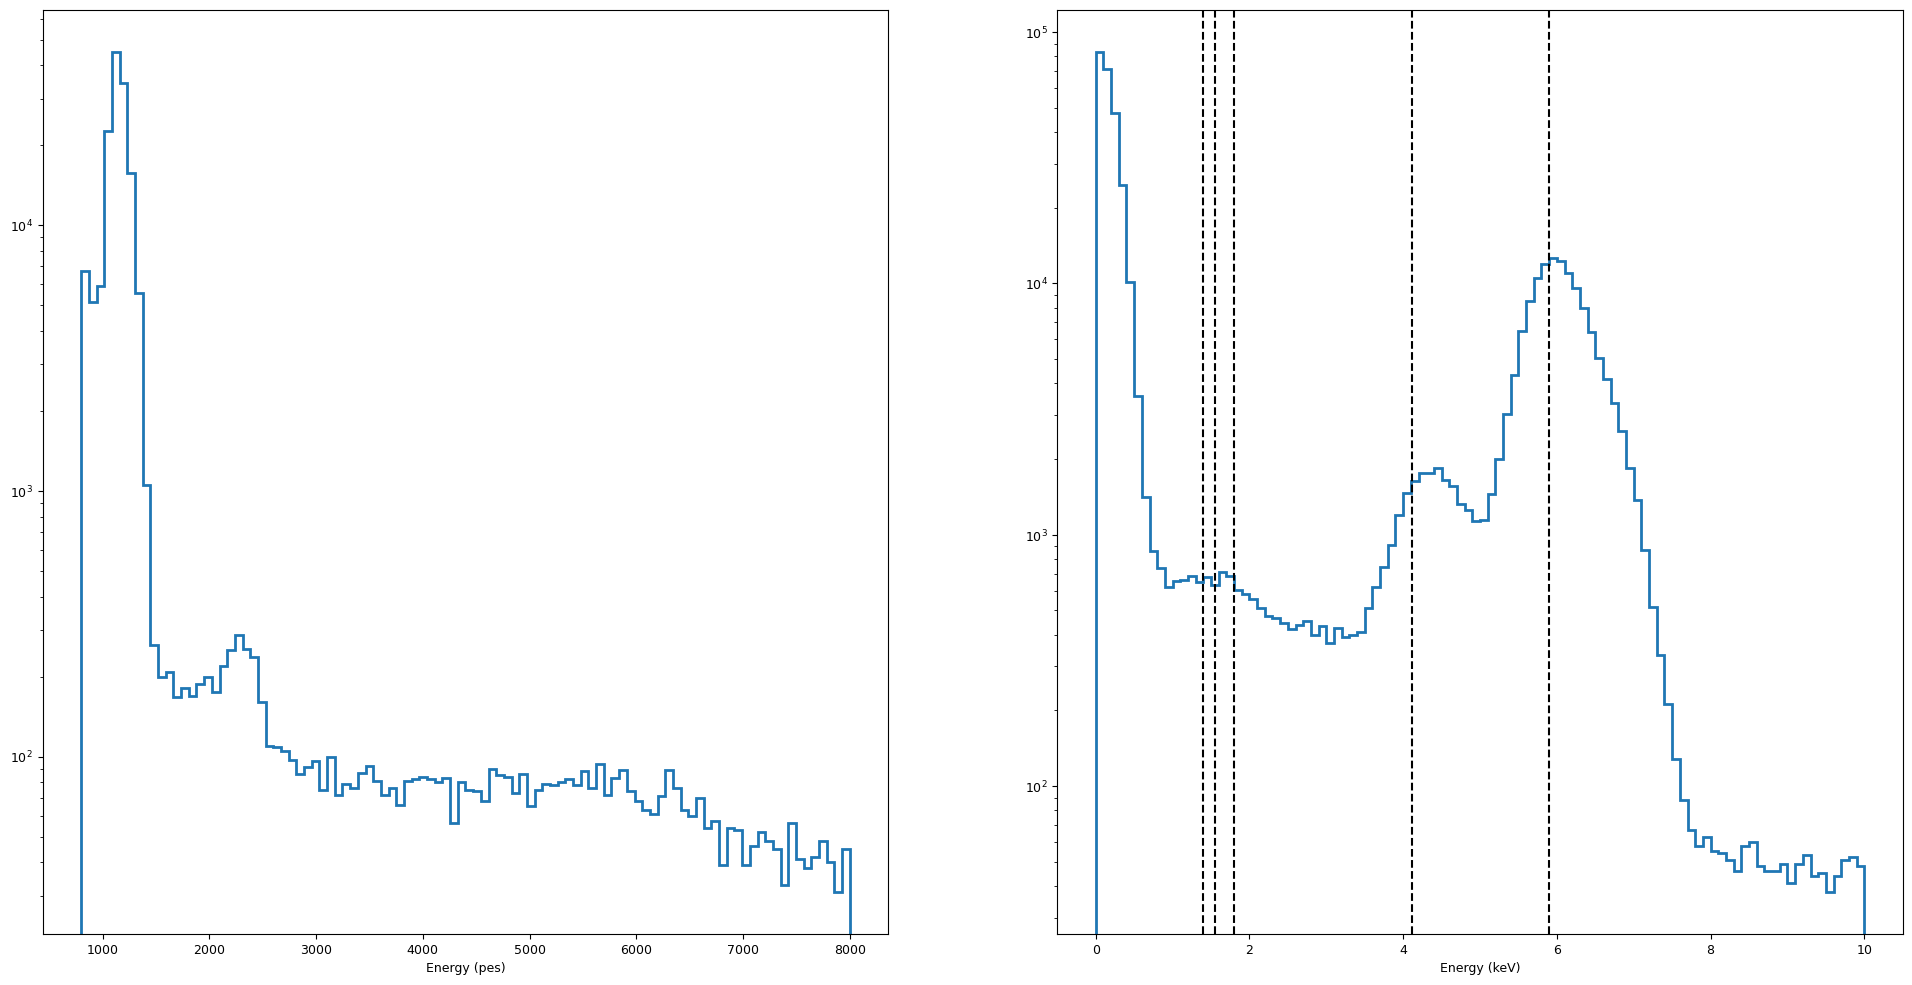

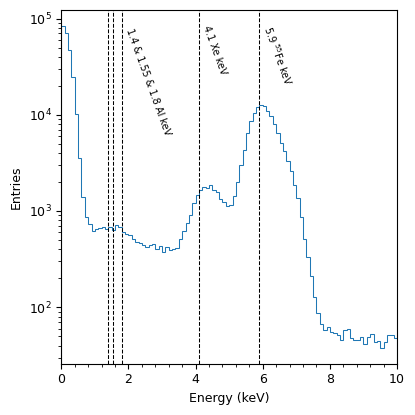

In [86]:
# ============================================================
# 1. FIGURE SETUP AND STYLE PARAMETERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

plot_size     = 4
font_size     = 9
leg_font_size = 7
text_size     = 7
dpi           = 1200
marker_size   = 1.5
line_width    = 0.75
padding       = 0.2
rot_text      = 290

# Set default font size for all Matplotlib text
mpl.rcParams["font.size"] = font_size

# Second figure (used for the Gaussian fits)
fig = plt.figure(figsize=(plot_size, plot_size),
                 tight_layout={'pad': padding})
axes2 = plt.gca()


# ============================================================
# 2. HISTOGRAM DEFINITIONS & GENERAL PARAMETERS
# ============================================================

enebins   = np.linspace(800,   8000, 101)
enebins_c = np.linspace(0.,    10,   101)

normed = False
var    = 'energy'          # variable to histogram
eref   = 5.9               # reference energy in keV (55Fe)

# ============================================================
# 3. RAW HISTOGRAM IN PES (axes[0]) AND FIRST ENERGY CALIBRATION
# ============================================================

# Histogram raw data (in PES)
y, x, *_ = axes[0].hist(
    data_1_s2[var],
    enebins,
    histtype='step',
    lw=2,
    weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2,
    label=label_1
)

# Convert bin edges to centers
x = coref.shift_to_bin_centers(x)

# First energy scale estimate: PES peak position / reference 5.9 keV
escale_1 = x[y.argmax()] / eref
print(x[y.argmax()])


# ============================================================
# 4. HISTOGRAM IN KEV (axes[1]) USING FIRST SCALING
# ============================================================

axes[1].hist(
    data_1_s2[var] / escale_1,
    enebins_c,
    histtype='step',
    lw=2,
    weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2,
    label=label_1
)
axes[1].set_xlabel('Energy (keV)')
axes[1].set_yscale('log')


# ============================================================
# 5. SECOND HISTOGRAM FOR FITTING (axes2) – REFINED CALIBRATION
# ============================================================

eref_kev = 5.9
erange   = [2000, 6000]

nsigma    = 1
eref      = 500
sigma_ref = 150 / nsigma

centers   = np.array([5.9, 6.5])     # relative peak positions
int_ratio = np.array([11142, 1299])  # relative intensities

mus, sigmas = [], []
noise, m_noise, poise, m_poise = [], [], [], []
thr_decay = []

enebins = np.linspace(0, 10000, 1001)

# Histogram with initial calibration
y, x, *_ = axes2.hist(
    data_1_s2[var] / escale_1,
    enebins_c,
    histtype='step',
    lw=line_width,
    weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2,
    label=label_1, alpha=1
)


# Recompute bin centers
x = coref.shift_to_bin_centers(x)

# Refined energy scaling
escale_1 = x[y.argmax()] / eref_kev

# Store calibrated variable in keV
data_1_s2[var + '_kev'] = data_1_s2[var] / escale_1

# Resolution scaling
new_sigma = sigma_ref * np.sqrt(escale_1)

# Range select for signal region
sels_e_1 = []
sels_e_1.append(coref.in_range(data_1_s2[var + '_kev'], *erange))


# ============================================================
# 6. MULTI-GAUSSIAN FIT OF THE 55Fe PEAK REGION
# ============================================================

# Fit window = ± nsigma around the peak
efit = [x[y.argmax()] - nsigma * new_sigma,
        x[y.argmax()] + nsigma * new_sigma]

xd = x.copy()
yd = y.copy()
sel_f = coref.in_range(xd, *efit)

# Base Gaussian model for the 5.9 keV peak
mod = GaussianModel(prefix='g1_')
pars = mod.guess(yd[sel_f], x=xd[sel_f])
pars['g1_amplitude'].set(min=0)

# Add additional Gaussians with constrained parameters
for i in range(1, len(centers)):
    g = GaussianModel(prefix=f'g{i+1}_')
    mod += g

    params = g.make_params(center=pars['g1_center'],
                           sigma=pars['g1_sigma'],
                           amplitude=pars['g1_amplitude'])

    # Peak positions tied by ratio of energies
    params[f'g{i+1}_center'].set(
        value=pars['g1_center'],
        vary=True,
        expr=f'g1_center * {centers[i] / centers[0]}'
    )

    # Sigmas scale with sqrt(E)
    params[f'g{i+1}_sigma'].set(
        value=pars['g1_center'],
        vary=True,
        expr=f'g1_sigma * {np.sqrt(centers[i] / centers[0])}'
    )

    # Amplitudes scaled by known intensities
    params[f'g{i+1}_amplitude'].set(
        value=pars['g1_center'],
        min=0,
        vary=True,
        expr=f'g1_amplitude * {int_ratio[i] / int_ratio[0]}'
    )

    pars.update(params)

# Perform the fit
out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

# ---- restrict plotting of Gaussians to ±2 sigma INSIDE the fit window ----
plot_range = [
    x[y.argmax()] - 0 * new_sigma,
    x[y.argmax()] + 0.5 * new_sigma
]
sel_plot_inside_fit = (xd[sel_f] >=  5.9 - 2) & ( xd[sel_f] <= 5.9 + 2)
print('center is :', pars['g1_center'])
print('borne inf is : ', x[y.argmax()])
print('sel_plot_inside_fit is :', sel_plot_inside_fit)
# Plot full model fit (still restricted to ±3σ fit window)
#axes2.plot(xd[sel_f][sel_plot_inside_fit], out.best_fit[sel_plot_inside_fit], '-', c='C3', lw=line_width)
#axes2.plot(sel_plot_inside_fit, out.best_fit[sel_plot_inside_fit], '-', c='C3', lw=line_width)

# Create a boolean mask for x values within ±2σ
#sel_plot = (xd >= plot_range[0]) & (xd <= plot_range[1])

# Plot the full model only within ±2σ
#axes2.plot(xd[sel_plot], out.best_fit[sel_plot], '-', c='C3', lw=line_width)



# Plot Gaussian components only inside ±2σ inside the fit window
components = out.eval_components(x=xd[sel_f])
cols = ['C1', 'C2']

#for (model_name, model_value), c in zip(components.items(), cols):
##    axes2.plot(
#        xd[sel_f][sel_plot_inside_fit],
#        model_value[sel_plot_inside_fit],
#        lw=line_width, ls='--', color=c, 
#    )


# ============================================================
# 7. EXTRACT μ AND σ OF MAIN PEAK AND STORE THEM
# ============================================================

result = out.result.params

#mu = np.array([
#    result['g1_center'].value,
#    result['g1_center'].stderr
#]) * escale_1 / eref_kev

#sigma = np.array([
#    result['g1_sigma'].value,
#    result['g1_sigma'].stderr
#]) * escale_1 / eref_kev

#mus.append(mu)
#sigmas.append(sigma)


# ============================================================
# 8. FINAL PLOTTING: STYLING, LINES, LABELS, ANNOTATIONS
# ============================================================

axes[0].set_xlabel('Energy (pes)')
axes[0].set_yscale('log')

axes2.set_xlabel('Energy (keV)')
axes2.set_ylabel('Entries')
axes2.set_xlim(0, 10)
#axes2.set_ylim(0, 1e5)

# Minor ticks
axes2.xaxis.set_minor_locator(AutoMinorLocator(5))
axes2.yaxis.set_minor_locator(AutoMinorLocator(5))

# Energy reference lines (escape peaks, Fe lines, etc.)
energy_lines = [1.4, 1.55, 1.8, 5.9, 4.109]
colors = ['k', 'k', 'k', 'k', 'k']
texts  = ['',' ',' 1.4 & 1.55 & 1.8 Al keV',
          r'5.9 $^{55}$Fe keV', '4.1 Xe keV']
ymin, ymax = plt.ylim()
for color, line, text in zip(colors, energy_lines, texts):
    axes[1].axvline(line, c=color, ls='--')
    axes2.axvline(line, c=color, ls='--', lw=line_width)
    axes2.text(
        x=line + 0.05,
        y=ymax,
        s=text,
        c=color,
        verticalalignment='top',
        rotation=rot_text,
        size=text_size
    )

# Mark background threshold region
#axes2.axvspan(0, 0.5, color='C7', alpha=0.2)
#axes2.axvline(0.5, c='C7', lw=line_width)
#axes2.text(
#    x=0.5 + 0.05,
#    y=axes2.get_ylim()[1],
#    s='Background induced threshold',
#    c='C7',
#    verticalalignment='top',
#    rotation=270,
#    size=text_size
#)

axes2.set_yscale('log')
#axes2.set_ylim(1e2, 5e5)

55Fe peak : 0.03431611054299399 0.1332455036113045
Al peak   : 0.8435047757611942 1.178556502355129
5
line is : 1.486
line is : 1.557
line is : 2.96
line is : 5.89
line is : 11.78


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Text(1.05, 30000.0, 'Background induced threshold')

/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: AutoMinorLocator does not work with logarithmic scale
  func(*args, **kwargs)


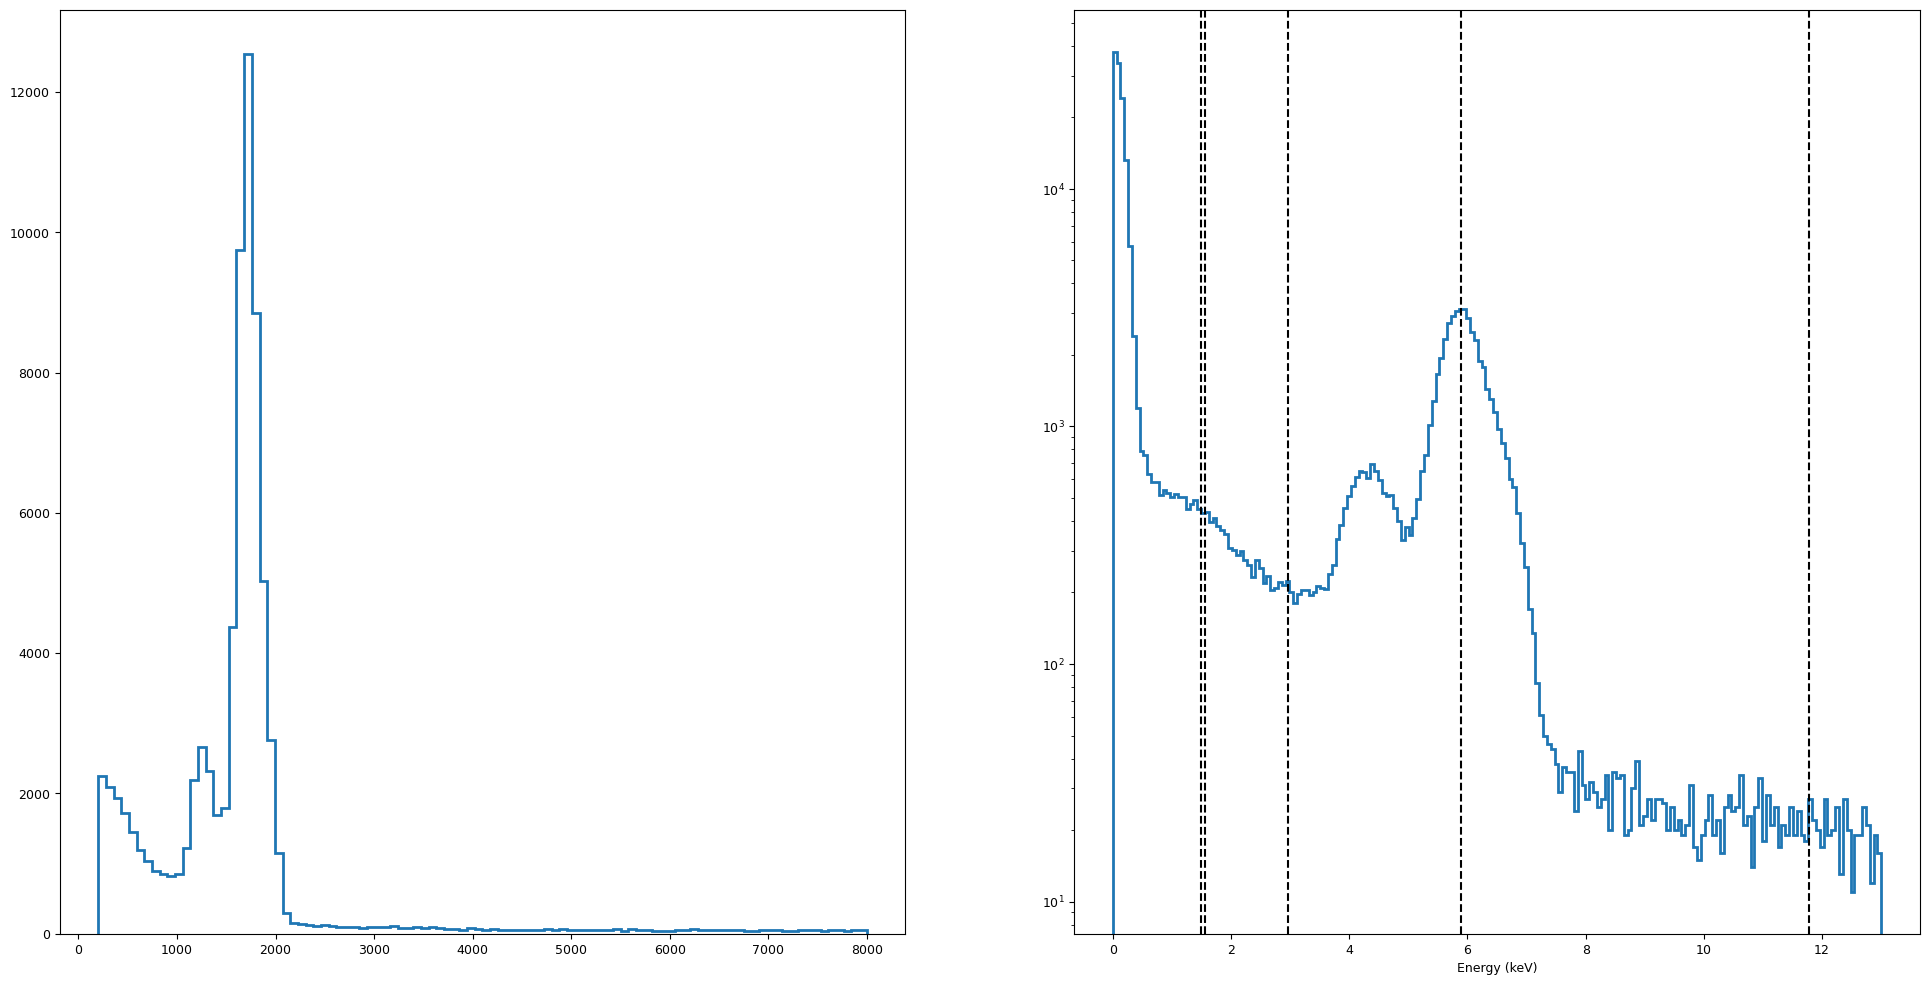

/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


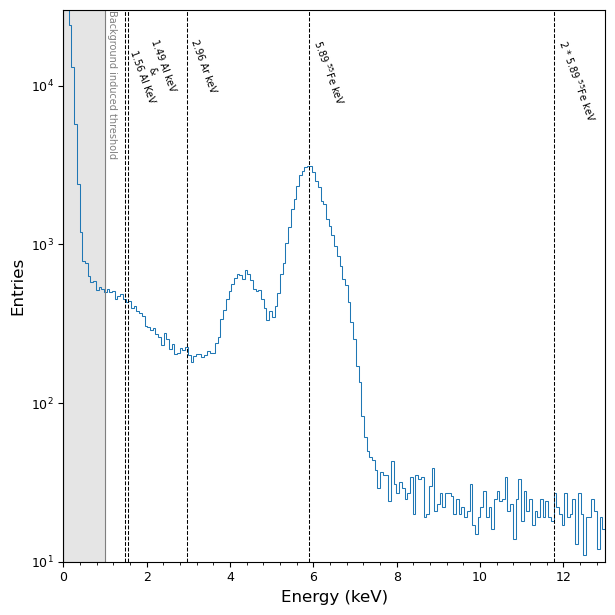

In [79]:
### ARGON

# ============================================================
# 1. FIGURE SETUP AND STYLE PARAMETERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

plot_size     = 6
font_size     = 9
leg_font_size = 7
text_size     = 7
dpi           = 1200
marker_size   = 1.5
line_width    = 0.75
padding       = 0.2
rot_text      = 290

# Set default font size for all Matplotlib text
mpl.rcParams["font.size"] = font_size

# Second figure (used for the Gaussian fits)
fig = plt.figure(figsize=(plot_size, plot_size),
                 tight_layout={'pad': padding})
axes2 = plt.gca()


# ============================================================
# 2. HISTOGRAM DEFINITIONS & GENERAL PARAMETERS
# ============================================================

enebins   = np.linspace(200,   8000, 101)
enebins_c = np.linspace(0.,    13,   201)

normed = False
var    = 'energy'
eref   = 5.9


# ============================================================
# 3. RAW HISTOGRAM IN PES
# ============================================================

y, x, *_ = axes[0].hist(
    data_1_s2[var], enebins, histtype='step', lw=2,
    weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2,
    label=label_1
)
x = coref.shift_to_bin_centers(x)

escale_1 = x[y.argmax()] / eref


# ============================================================
# 4. HISTOGRAM IN KEV (FIRST SCALING)
# ============================================================

axes[1].hist(
    data_1_s2[var] / escale_1,
    enebins_c, histtype='step', lw=2,
    weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2,
    label=label_1
)
axes[1].set_xlabel('Energy (keV)')
axes[1].set_yscale('log')


# ============================================================
# 5. SECOND HISTOGRAM FOR FITTING (axes2)
# ============================================================

eref_kev = 5.9
nsigma = 1
centers = np.array([5.9, 6.5])
int_ratio = np.array([11142, 1299])

y, x, *_ = axes2.hist(
    data_1_s2[var] / escale_1,
    enebins_c, histtype='step', lw=line_width,
    weights=weights_1_s2, alpha=1
)

x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()] / eref_kev
data_1_s2[var + '_kev'] = data_1_s2[var] / escale_1


# ============================================================
# 6. FIRST FIT (55Fe doublet : 5.9 / 6.5 keV)
# ============================================================

xd = x.copy()
yd = y.copy()

peak_center = x[y.argmax()]
sigma_ref = 150 / nsigma
new_sigma = sigma_ref * np.sqrt(escale_1)

efit = [peak_center - nsigma * new_sigma,
        peak_center + nsigma * new_sigma]

sel_f = coref.in_range(xd, *efit)

mod = GaussianModel(prefix='g1_')
pars = mod.guess(yd[sel_f], x=xd[sel_f])
pars['g1_amplitude'].set(min=0)

for i in range(1, len(centers)):
    g = GaussianModel(prefix=f'g{i+1}_')
    mod += g
    params = g.make_params(center=pars['g1_center'],
                           sigma=pars['g1_sigma'],
                           amplitude=pars['g1_amplitude'])

    params[f'g{i+1}_center'].set(expr=f"g1_center * {centers[i]/centers[0]}")
    params[f'g{i+1}_sigma'].set(expr=f"g1_sigma * {np.sqrt(centers[i]/centers[0])}")
    params[f'g{i+1}_amplitude'].set(expr=f"g1_amplitude * {int_ratio[i]/int_ratio[0]}")

    pars.update(params)

out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

# Plot window: ±2 keV around 5.9
sel_plot1 = (xd >= 5.9 - 2) & (xd <= 5.9 + 3)
axes2.plot(xd[sel_plot1], out.eval(x=xd)[sel_plot1],
           '-', c='C3', lw=line_width)

components = out.eval_components(x=xd)
cols = ['C1', 'C2']
for (name, model), c in zip(components.items(), cols):
    axes2.plot(xd[sel_plot1], model[sel_plot1],
               '--', lw=line_width, color=c)


# ============================================================
# 7. SECOND FIT (Al doublet : 1.486 / 1.557 keV)
# ============================================================

centers_low = np.array([1.486, 1.557])
int_ratio_low = np.array([1, 0.6])   # mettre les vraies valeurs si connues

# window of fit : ±1 keV
sel_low = (xd >= 1) & (xd <= 2.2)
xd_low = xd[sel_low]
yd_low = yd[sel_low]

mod2 = GaussianModel(prefix="h1_")
pars2 = mod2.guess(yd_low, x=xd_low)
pars2["h1_amplitude"].set(min=0)

# second peak
g2 = GaussianModel(prefix="h2_")
mod2 += g2

params2 = g2.make_params(center=pars2["h1_center"],
                         sigma=pars2["h1_sigma"],
                         amplitude=pars2["h1_amplitude"])

params2["h2_center"].set(expr=f"h1_center * {centers_low[1]/centers_low[0]}")
params2["h2_sigma"].set(expr=f"h1_sigma * {np.sqrt(centers_low[1]/centers_low[0])}")
params2["h2_amplitude"].set(expr=f"h1_amplitude * {int_ratio_low[1]/int_ratio_low[0]}")

pars2.update(params2)

out_low = mod2.fit(yd_low, pars2, x=xd_low)

# plotting window : ±0.4 keV around 1.5
sel_plot2 = (xd >= 0) & (xd <= 5)
#axes2.plot(xd[sel_plot2], out_low.eval(x=xd)[sel_plot2],
          # '-', c='C4', lw=line_width)

components_low = out_low.eval_components(x=xd)
cols2 = ['C5', 'C6']
#for (name, model), c in zip(components_low.items(), cols2):
   # axes2.plot(xd[sel_plot2], model[sel_plot2],
              # '--', lw=line_width, color=c)


# ============================================================
# 8. EXTRACT μ AND σ FOR BOTH FITS
# ============================================================

result = out.result.params
result_low = out_low.result.params

mu_59 = result['g1_center'].value
sigma_59 = result['g1_sigma'].value

mu_15 = result_low['h1_center'].value
sigma_15 = result_low['h1_sigma'].value

print("55Fe peak :", mu_59, sigma_59)
print("Al peak   :", mu_15, sigma_15)


# ============================================================
# 9. PLOTTING STYLING
# ============================================================

axes2.set_xlabel('Energy (keV)', fontsize=12)
axes2.set_ylabel('Entries', fontsize=12)
axes2.set_yscale('log')
axes2.set_xlim(0, 13)
axes2.set_ylim(1e1, 3e4)
axes2.xaxis.set_minor_locator(AutoMinorLocator(5))
axes2.yaxis.set_minor_locator(AutoMinorLocator(5))
#axes2.axvspan(0, 0.5, color='C7', alpha=0.2)
#axes2.axvline(0.5, c='C7', lw=line_width)

energy_lines = [1.486, 1.557, 2.96, 5.89, 2 * 5.89]
y_line= [2e4]
y_line += [2e4]*(len(energy_lines) - 1)
print(len(y_line))
colors = ['k', 'k', 'k', 'k', 'k']
texts  = [  '1.49 Al keV \n        &     \n 1.56 Al KeV', ' ','2.96 Ar keV',r'5.89 $^{55}$Fe keV', r'2 * 5.89 $^{55}$Fe keV']

for color, line, text, yline in zip(colors, energy_lines, texts, y_line):
    axes[1].axvline(line, c=color, ls='--')
    print('line is :', line)
    axes2.axvline(line, c=color, ls='--', lw=line_width)
    axes2.text(x=line + 0.05,y=yline,s=text,c=color,verticalalignment='top',rotation=rot_text,size=text_size)

axes2.axvspan(0, 1, color='C7', alpha=0.2)
axes2.axvline(1, c='C7', lw=line_width)
axes2.text(
    x=1 + 0.05,
    y=axes2.get_ylim()[1],
    s='Background induced threshold',
    c='C7',
    verticalalignment='top',
    rotation=270,
    size=text_size
)


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/opt

55Fe peak : 5.883729763681052 0.3453152838069893
Al peak   : 1.4326272970625196 0.7053690824153351
Xe 4.11keV: 4.342870849168457 0.49999999998607186
2×55Fe    : 11.847053346394159 0.8574614002245399
Exp @0 keV: 0.16478294713940375


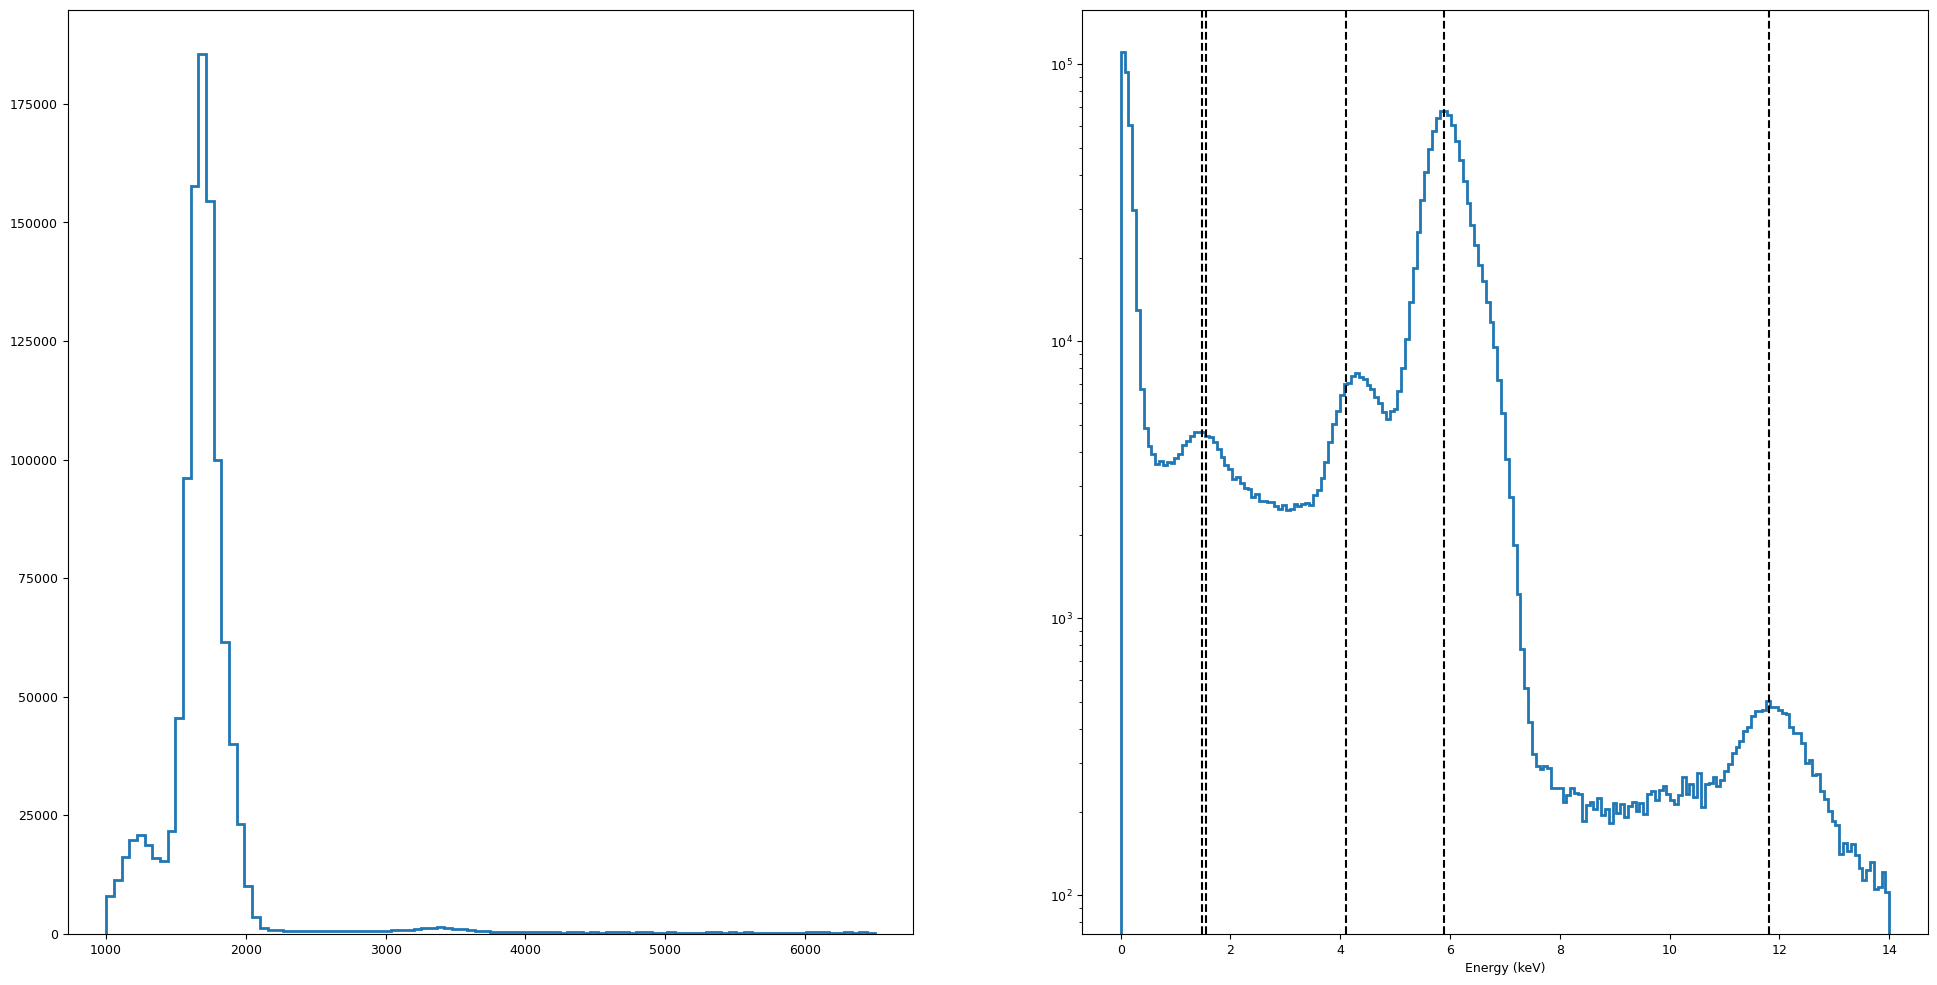

/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


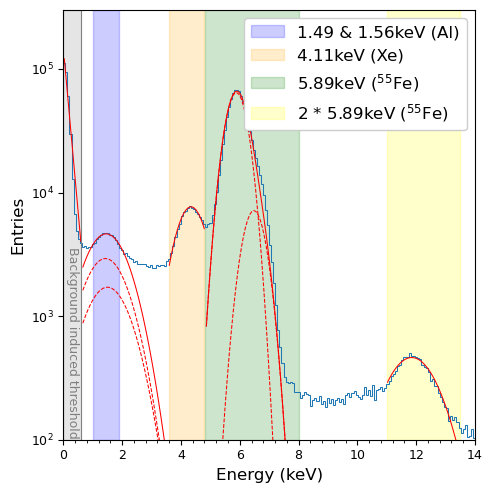

In [332]:
### XENON

# ============================================================
# 1. FIGURE SETUP AND STYLE PARAMETERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

plot_size     = 5
font_size     = 9
leg_font_size = 7
text_size     = 9
dpi           = 1200
marker_size   = 1.5
line_width    = 0.75
padding       = 0.2
rot_text      = 290

# Set default font size for all Matplotlib text
mpl.rcParams["font.size"] = font_size

# Second figure (used for the Gaussian fits)
fig = plt.figure(figsize=(plot_size, plot_size),
                 tight_layout={'pad': padding})
axes2 = plt.gca()


# ============================================================
# 2. HISTOGRAM DEFINITIONS & GENERAL PARAMETERS
# ============================================================

enebins   = np.linspace(1000,   6500, 101)
enebins_c = np.linspace(0.,    14,   201)

normed = False
var    = 'energy'
eref   = 5.9


# ============================================================
# 3. RAW HISTOGRAM IN PES
# ============================================================

y, x, *_ = axes[0].hist(
    data_1_s2[var], enebins, histtype='step', lw=2,
    weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2,
    label=label_1
)
x = coref.shift_to_bin_centers(x)

escale_1 = x[y.argmax()] / eref


# ============================================================
# 4. HISTOGRAM IN KEV (FIRST SCALING)
# ============================================================

axes[1].hist(
    data_1_s2[var] / escale_1,
    enebins_c, histtype='step', lw=2,
    weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2,
    label=label_1
)
axes[1].set_xlabel('Energy (keV)')
axes[1].set_yscale('log')


# ============================================================
# 5. SECOND HISTOGRAM FOR FITTING (axes2)
# ============================================================

eref_kev = 5.9
nsigma = 1
centers = np.array([5.9, 6.5])
int_ratio = np.array([11142, 1299])

y, x, *_ = axes2.hist(
    data_1_s2[var] / escale_1,
    enebins_c, histtype='step', lw=line_width,
    weights=weights_1_s2, alpha=1
)

x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()] / eref_kev
data_1_s2[var + '_kev'] = data_1_s2[var] / escale_1


# ============================================================
# 6. FIRST FIT (55Fe doublet : 5.9 / 6.5 keV)
# ============================================================

xd = x.copy()
yd = y.copy()

peak_center = x[y.argmax()]
sigma_ref = 150 / nsigma
new_sigma = sigma_ref * np.sqrt(escale_1)

efit = [peak_center - nsigma * new_sigma,
        peak_center + nsigma * new_sigma]

sel_f = coref.in_range(xd, *efit)

mod = GaussianModel(prefix='g1_')
pars = mod.guess(yd[sel_f], x=xd[sel_f])
pars['g1_amplitude'].set(min=0)

for i in range(1, len(centers)):
    g = GaussianModel(prefix=f'g{i+1}_')
    mod += g
    params = g.make_params(center=pars['g1_center'],
                           sigma=pars['g1_sigma'],
                           amplitude=pars['g1_amplitude'])

    params[f'g{i+1}_center'].set(expr=f"g1_center * {centers[i]/centers[0]}")
    params[f'g{i+1}_sigma'].set(expr=f"g1_sigma * {np.sqrt(centers[i]/centers[0])}")
    params[f'g{i+1}_amplitude'].set(expr=f"g1_amplitude * {int_ratio[i]/int_ratio[0]}")

    pars.update(params)

out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

sel_plot1 = (xd >= 4.81) & (xd <= 5.9 + 2)
axes2.plot(xd[sel_plot1], out.eval(x=xd)[sel_plot1],
           '-', c='red', lw=line_width)

components = out.eval_components(x=xd)
cols = ['red', 'red']
for (name, model), c in zip(components.items(), cols):
    axes2.plot(xd[sel_plot1], model[sel_plot1],
               '--', lw=line_width, color=c)


# ============================================================
# 7. SECOND FIT (Al doublet : 1.486 / 1.557 keV)
# ============================================================

centers_low = np.array([1.486, 1.557])
int_ratio_low = np.array([1, 0.6])

sel_low = (xd >= 1) & (xd <= 2.2)
xd_low = xd[sel_low]
yd_low = yd[sel_low]

mod2 = GaussianModel(prefix="h1_")
pars2 = mod2.guess(yd_low, x=xd_low)
pars2["h1_amplitude"].set(min=0)

g2 = GaussianModel(prefix="h2_")
mod2 += g2

params2 = g2.make_params(center=pars2["h1_center"],
                         sigma=pars2["h1_sigma"],
                         amplitude=pars2["h1_amplitude"])

params2["h2_center"].set(expr=f"h1_center * {centers_low[1]/centers_low[0]}")
params2["h2_sigma"].set(expr=f"h1_sigma * {np.sqrt(centers_low[1]/centers_low[0])}")
params2["h2_amplitude"].set(expr=f"h1_amplitude * {int_ratio_low[1]/int_ratio_low[0]}")

pars2.update(params2)

out_low = mod2.fit(yd_low, pars2, x=xd_low)

sel_plot2 = (xd >= 0.6) & (xd <= 5)
axes2.plot(xd[sel_plot2], out_low.eval(x=xd)[sel_plot2],
           '-', c='red', lw=line_width)

components_low = out_low.eval_components(x=xd)
cols2 = ['red', 'red']
for (name, model), c in zip(components_low.items(), cols2):
    axes2.plot(xd[sel_plot2], model[sel_plot2], '--', lw=line_width, color=c)


# ============================================================
# 7bis. ADDITIONAL FIT 4.11 keV
# ============================================================

sel_411 = (xd >= 3.6) & (xd <= 4.8)
xd_411 = xd[sel_411]
yd_411 = yd[sel_411]

mod_411 = GaussianModel(prefix="Xe411_")
pars_411 = mod_411.guess(yd_411, x=xd_411)
pars_411["Xe411_center"].set(value=4.11)
pars_411["Xe411_sigma"].set(value=0.1, min=0.01, max=0.5)
pars_411["Xe411_amplitude"].set(min=0)

out_411 = mod_411.fit(yd_411, pars_411, x=xd_411)

axes2.plot(xd_411, out_411.eval(x=xd_411), '-', c='red', lw=line_width)


# ============================================================
# 7ter. ADDITIONAL FIT 2×5.9 keV
# ============================================================

sel_2fe = (xd >= 11.) & (xd <= 13.5)
xd_2fe = xd[sel_2fe]
yd_2fe = yd[sel_2fe]

mod_2fe = GaussianModel(prefix="Fe2_")
pars_2fe = mod_2fe.guess(yd_2fe, x=xd_2fe)
pars_2fe["Fe2_center"].set(value=2*5.9)
pars_2fe["Fe2_sigma"].set(value=0.25, min=0.05, max=1.0)
pars_2fe["Fe2_amplitude"].set(min=0)

out_2fe = mod_2fe.fit(yd_2fe, pars_2fe, x=xd_2fe)

axes2.plot(xd_2fe, out_2fe.eval(x=xd_2fe), '-', c='red', lw=line_width)


# ============================================================
# 7quater. ADDITIONAL EXPONENTIAL DECAY FIT AT 0 keV
# ============================================================

from lmfit.models import ExponentialModel

sel_exp0 = (xd >= 0) & (xd <= 0.6)  # fenêtre autour du pic en 0
xd_exp0 = xd[sel_exp0]
yd_exp0 = yd[sel_exp0]

exp_mod = ExponentialModel(prefix="exp0_")
pars_exp0 = exp_mod.guess(yd_exp0, x=xd_exp0)
pars_exp0["exp0_amplitude"].set(min=0)
pars_exp0["exp0_decay"].set(value=1.0, min=0.01, max=10.0)

out_exp0 = exp_mod.fit(yd_exp0, pars_exp0, x=xd_exp0)

axes2.plot(xd_exp0, out_exp0.eval(x=xd_exp0), '-', c='red', lw=line_width)


# ============================================================
# 8. EXTRACT μ AND σ FOR ALL FITS
# ============================================================

result = out.result.params
result_low = out_low.result.params
result_411 = out_411.result.params
result_2fe = out_2fe.result.params
result_exp0 = out_exp0.result.params

mu_59 = result['g1_center'].value
sigma_59 = result['g1_sigma'].value

mu_15 = result_low['h1_center'].value
sigma_15 = result_low['h1_sigma'].value

mu_411 = result_411['Xe411_center'].value
sigma_411 = result_411['Xe411_sigma'].value

mu_2fe = result_2fe['Fe2_center'].value
sigma_2fe = result_2fe['Fe2_sigma'].value

print("55Fe peak :", mu_59, sigma_59)
print("Al peak   :", mu_15, sigma_15)
print("Xe 4.11keV:", mu_411, sigma_411)
print("2×55Fe    :", mu_2fe, sigma_2fe)
print("Exp @0 keV:", result_exp0["exp0_decay"].value)


# ============================================================
# 9. PLOTTING STYLING
# ============================================================

axes2.set_xlabel('Energy (keV)', fontsize=12)
axes2.set_ylabel('Entries', fontsize=12)
axes2.set_yscale('log')
axes2.set_xlim(0, 14)
axes2.set_ylim(1e2, 3e5)
axes2.xaxis.set_minor_locator(AutoMinorLocator(5))
axes2.yaxis.set_minor_locator(AutoMinorLocator(5))
axes2.axvspan(0, 0.6, color='C7', alpha=0.2)
axes2.axvline(0.6, c='C7', lw=line_width)

energy_lines = [1.486, 1.557, 5.89, 4.11, 2*5.9]
y_line= [2e5]*len(energy_lines)
colors = ['k', 'k', 'k', 'k', 'k']
texts  = [ '1.49 Al keV \n        &     \n 1.56 Al KeV', ' ',
          r'5.89 $^{55}$Fe keV', '4.11 Xe keV', r'2 × 5.89 $^{55}$Fe keV']

for color, line, text, yline in zip(colors, energy_lines, texts, y_line):
    axes[1].axvline(line, c=color, ls='--')
    #axes2.axvline(line, c=color, ls='--', lw=line_width)
    #axes2.text(
     #   x=line + 0.05,
      #  y=yline,
       # s=text,
        #c=color,
        #verticalalignment='top',
        #rotation=rot_text,
        #size=text_size
    #)

axes2.text(
    x=0.10,
    y=axes2.get_ylim()[0] + 3.5e3,
    s='Background induced threshold',
    c='C7',
    verticalalignment='top',
    rotation=270,
    size=text_size
)

#axes2.axvspan(0, 1, color='C7', alpha=0.2)
axes2.axvspan(1, 1.9, color='blue', alpha=0.2, label='1.49 & 1.56keV (Al)')
axes2.axvspan(3.6, 4.8, color='orange', alpha=0.2, label='4.11keV (Xe)')
axes2.axvspan(4.81, 8, color='green', alpha=0.2, label='5.89keV ($^{55}$Fe)')
axes2.axvspan(11, 13.5, color='yellow', alpha=0.2, label='2 * 5.89keV ($^{55}$Fe)')

plt.legend(fontsize=12, framealpha=1)

plt.savefig(
    "/Users/ldonneger/Desktop/Energy_spectrum_Xe_2661-2668.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300
)


In [71]:
#len(out.best_fit[sel_plot_inside_fit])
len(xd)
len(out.best_fit)


155

In [56]:
# Plot full model fit (still restricted to ±3σ fit window)
axes2.plot(xd[sel_f], out.best_fit, '-', c='C3', lw=line_width)


8375.0


(0.0, 1.0)

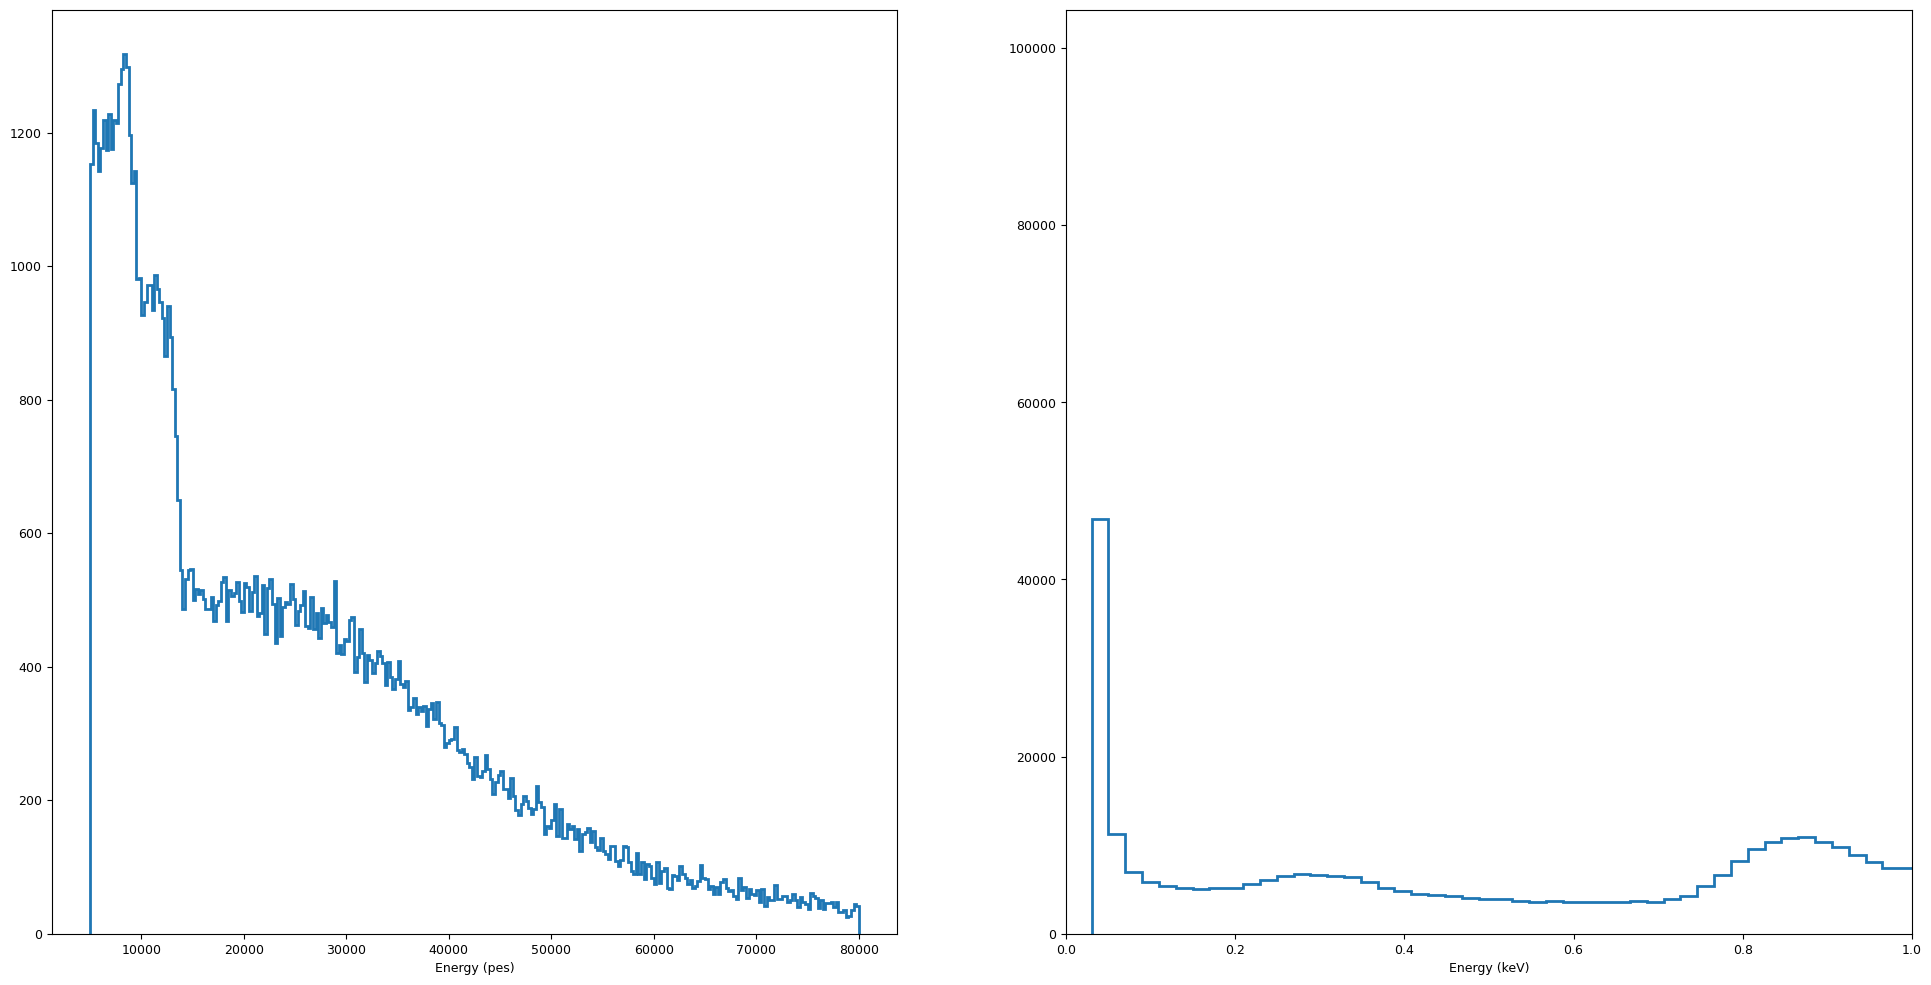

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(5000, 80000, 301)
#enebins = np.linspace(00, 2000, 201)
enebins_c = np.linspace(0.03, 6, 301)
normed = False
var    = 's1_energy'
#var    = 'e_pmt0_s1'
#var    = 'ped_sum_pmt1'
#var    = 'e_pmt0'

eref = 5.9
#eref = 0.3
#eref = 5.9

y,x, *_ = axes[0].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);
x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()]/eref
print(x[y.argmax()])
#escale_1 = 375/eref
#enebins = np.linspace(0.01, 2, 51)
axes[1].hist(data_1_s2[var]/escale_1, enebins_c, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);

for ax in axes:
    #ax.set_yscale('log')
    pass

axes[0].set_xlabel('Energy (pes)')
axes[1].set_xlabel('Energy (keV)')

ar_xray   = [2.9, 3.2][:1]
colors    = ['b'] * len(ar_xray)
#al_xray   = [1.5]
#colors   += ['k'] * fe_lines
fe_lines  = [5.9, 6.5]
fe_lines  = [5.9]
fe_lines  = [feline*i for feline in fe_lines for i in range(1, 3)]
colors   += ['k'] * len(fe_lines)
kr_line   = [41.5]
colors   += ['g'] * len(fe_lines)
#cu_lines = [9.4]
#colors   += ['r'] * len(cu_lines)
#
#am_lines = [13.9, 17.7, 26.3, 59.6][:2] # From 2212.11515
#colors   += ['g'] * len(am_lines)
energy_lines = ar_xray  + fe_lines #+kr_line#+  am_lines

for color, line in zip(colors, energy_lines):
    axes[1].axvline(line, c=color, ls='--')
    pass
erange = [2300, 5000]
erange = [800, 1600]
erange = [400, 600]
erange = [6000, 11000]
#axes[0].axvspan(*erange, alpha=0.2)
erange = [30, 50]
#axes[1].axvspan(*erange, alpha=0.2)
sel_e_1 = coref.in_range(data_1_s2[var]/escale_1, *erange)


axes[1].set_xlim(0, 1)
#mcpath = f'/home/ander/Work/GaP/nexus_quick_sim/data/SummaryDST_55Fe_{pressure}bar.h5'
#
#mc_dst = pd.read_hdf(mcpath)

In [14]:
1.4

268.1818181818182

In [52]:
data_1_s2

,event,timestamp,x,y,r,energy,height,d_energy,d_height,ped_sum,...,ped_sum_pmt5,e0_pmt5,e_pmt6,h_pmt6,e_pmt6_s1,h_pmt6_s1,ped_sum_pmt6,e0_pmt6,file,sub_energy
0,9106224,91213935707,-0.135468,1.285262,1.292381,2084.505551,5.385563,2084.446751,3.348120,-0.618948,...,0.060306,-0.008800,240.139797,2.015772,47.150302,0.655031,1.058814,-0.039816,Run_656_file_10_raw.h5,1526.505551
1,9106282,91214098721,4.426719,0.499271,4.454786,-365143.197631,2.346656,-365141.534639,0.463862,-618.184343,...,-292.230635,-1.093258,-47012.293545,-1.175927,-18326.231836,-1.175927,-410.790802,-1.697062,Run_656_file_10_raw.h5,-365701.197631
2,9134194,91277381513,0.793671,-0.105297,0.800626,1071.122337,15.727203,1071.420998,6.679100,-0.480560,...,0.351782,-0.009589,197.934762,2.767548,88.930708,1.464711,0.347423,0.046066,Run_656_file_10_raw.h5,513.122337
3,9134438,91277698716,1.669771,-1.110418,2.005284,30280.186925,35.071241,30279.625870,32.358495,-0.691545,...,0.073707,-0.033027,2129.739157,3.983548,101.027105,2.072720,0.670031,-0.011820,Run_656_file_10_raw.h5,29722.186925
4,9134575,91277972486,1.353902,-0.996516,1.681099,18013.072218,21.446553,18013.334851,19.521489,-0.431788,...,-0.154114,-0.056136,1344.650784,2.681133,92.185734,1.349344,0.852014,-0.011397,Run_656_file_10_raw.h5,17455.072218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15414,9105866,91212703277,10.304900,-4.097463,11.089642,-469.915762,1.064183,-470.280136,0.503561,-0.498770,...,-0.110560,0.010766,2.829018,0.187002,3.945736,0.187002,-0.194392,-0.015662,Run_656_file_9_raw.h5,-1027.915762
15415,9105905,91212860299,1.741783,-0.805930,1.919201,30562.268386,40.935962,30562.901273,38.318611,-0.428269,...,-0.137363,-0.009783,2120.030606,3.983291,96.790471,2.188270,1.133262,0.045827,Run_656_file_9_raw.h5,30004.268386
15416,9105991,91213157778,-35.275357,1.777337,35.320104,85.582142,1.050656,85.339468,0.425486,-0.773408,...,0.070356,-0.009172,66.077977,0.249244,27.050762,0.249244,0.955414,0.017629,Run_656_file_9_raw.h5,-472.417858
15417,9106039,91213343522,1.647042,-1.053717,1.955266,32184.741868,44.441687,32184.711556,41.437515,-0.510127,...,0.060306,-0.008800,2296.509223,4.100312,93.212838,1.118262,1.087766,0.075992,Run_656_file_9_raw.h5,31626.741868


188500.0


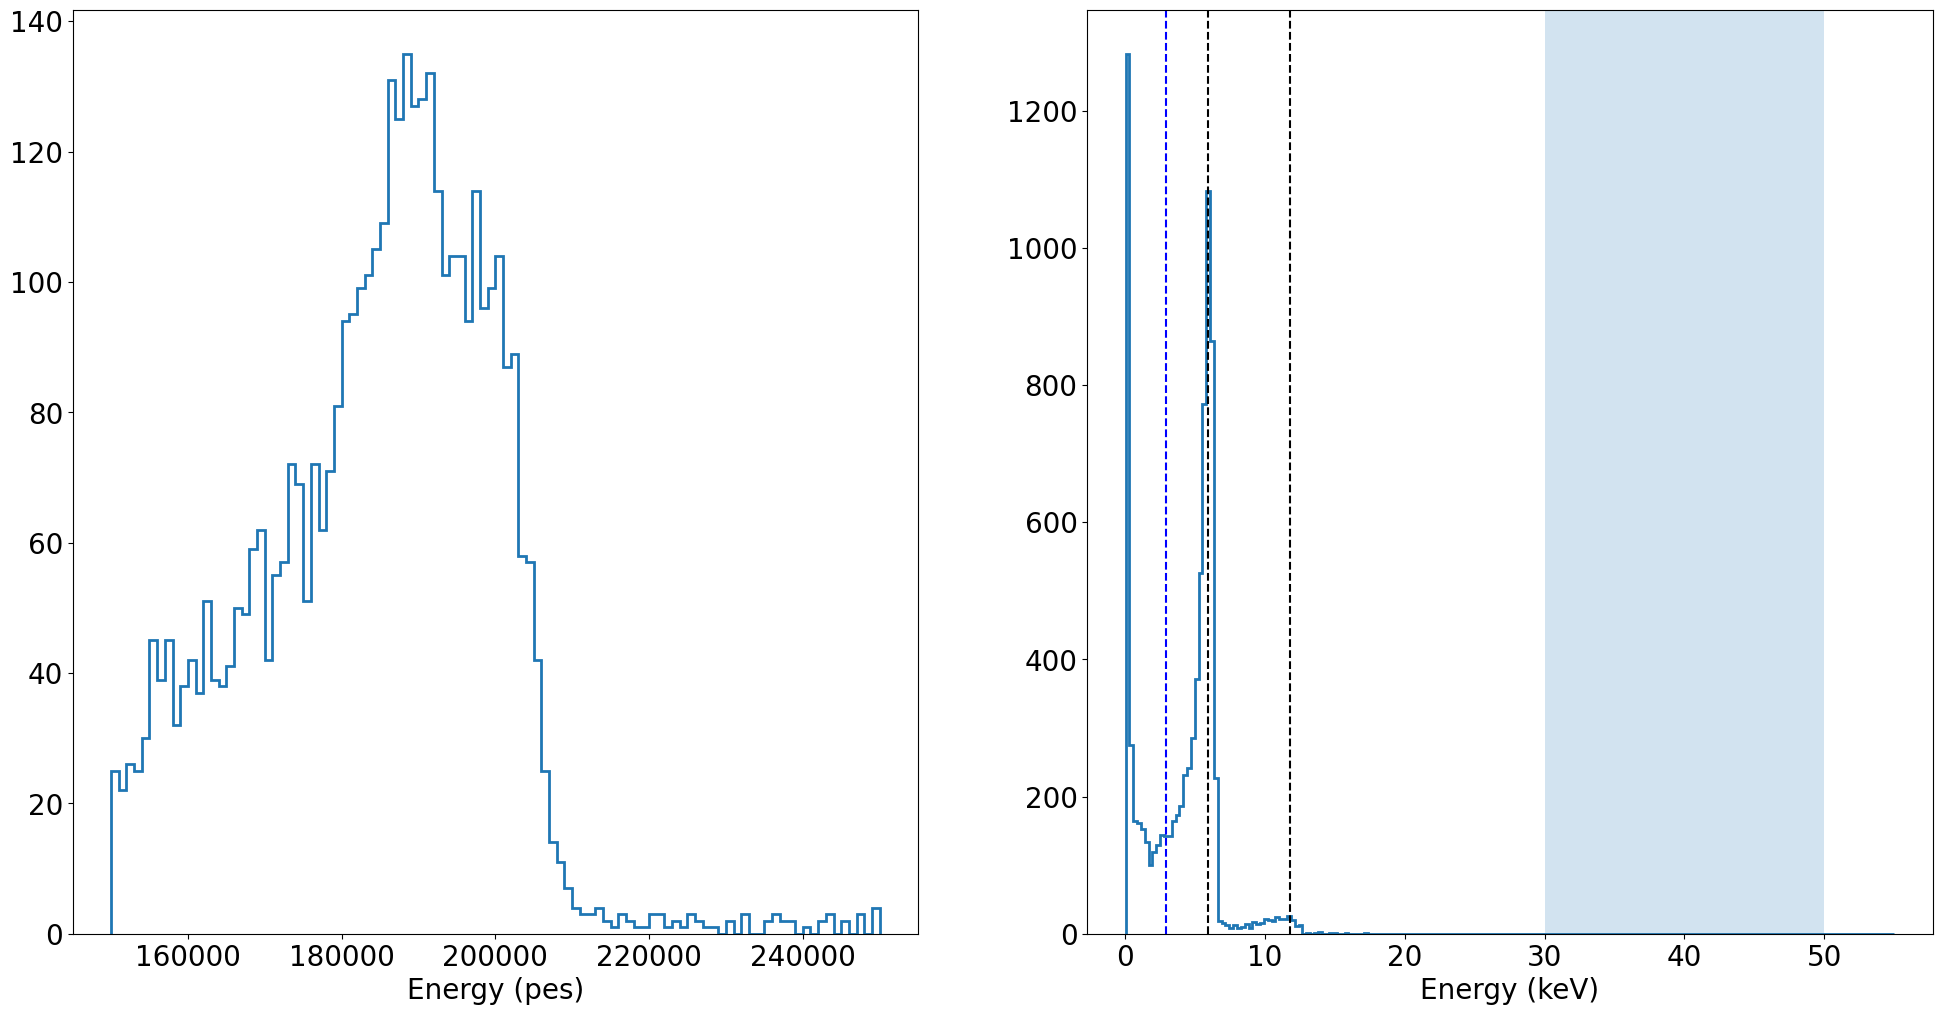

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(150e3, 250000, 101)
#enebins = np.linspace(00, 2000, 201)
enebins_c = np.linspace(0.03, 55, 201)
normed = False
var    = 'sub_energy'
#var    = 'e_pmt0'

eref = 5.9
#eref = 0.3
#eref = 5.9

y,x, *_ = axes[0].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);
x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()]/eref
print(x[y.argmax()])
#escale_1 = 375/eref
#enebins = np.linspace(0.01, 2, 51)
axes[1].hist(data_1_s2[var]/escale_1, enebins_c, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);

for ax in axes:
    #ax.set_yscale('log')
    pass

axes[0].set_xlabel('Energy (pes)')
axes[1].set_xlabel('Energy (keV)')

ar_xray   = [2.9, 3.2][:1]
colors    = ['b'] * len(ar_xray)
#al_xray   = [1.5]
#colors   += ['k'] * fe_lines
fe_lines  = [5.9, 6.5]
fe_lines  = [5.9]
fe_lines  = [feline*i for feline in fe_lines for i in range(1, 3)]
colors   += ['k'] * len(fe_lines)
kr_line   = [41.5]
colors   += ['g'] * len(fe_lines)
#cu_lines = [9.4]
#colors   += ['r'] * len(cu_lines)
#
#am_lines = [13.9, 17.7, 26.3, 59.6][:2] # From 2212.11515
#colors   += ['g'] * len(am_lines)
energy_lines = ar_xray  + fe_lines #+kr_line#+  am_lines

for color, line in zip(colors, energy_lines):
    axes[1].axvline(line, c=color, ls='--')
    pass
erange = [2300, 5000]
erange = [800, 1600]
erange = [400, 600]
erange = [6000, 11000]
#axes[0].axvspan(*erange, alpha=0.2)
erange = [30, 50]
axes[1].axvspan(*erange, alpha=0.2)
sel_e_1 = coref.in_range(data_1_s2[var]/escale_1, *erange)



#mcpath = f'/home/ander/Work/GaP/nexus_quick_sim/data/SummaryDST_55Fe_{pressure}bar.h5'
#
#mc_dst = pd.read_hdf(mcpath)

In [43]:
575 / (5495000/40)*100

0.41856232939035487

In [30]:
556 * 5495 / 59.5

51348.23529411765

In [24]:
131000 * 59.5/5495

1418.4713375796177

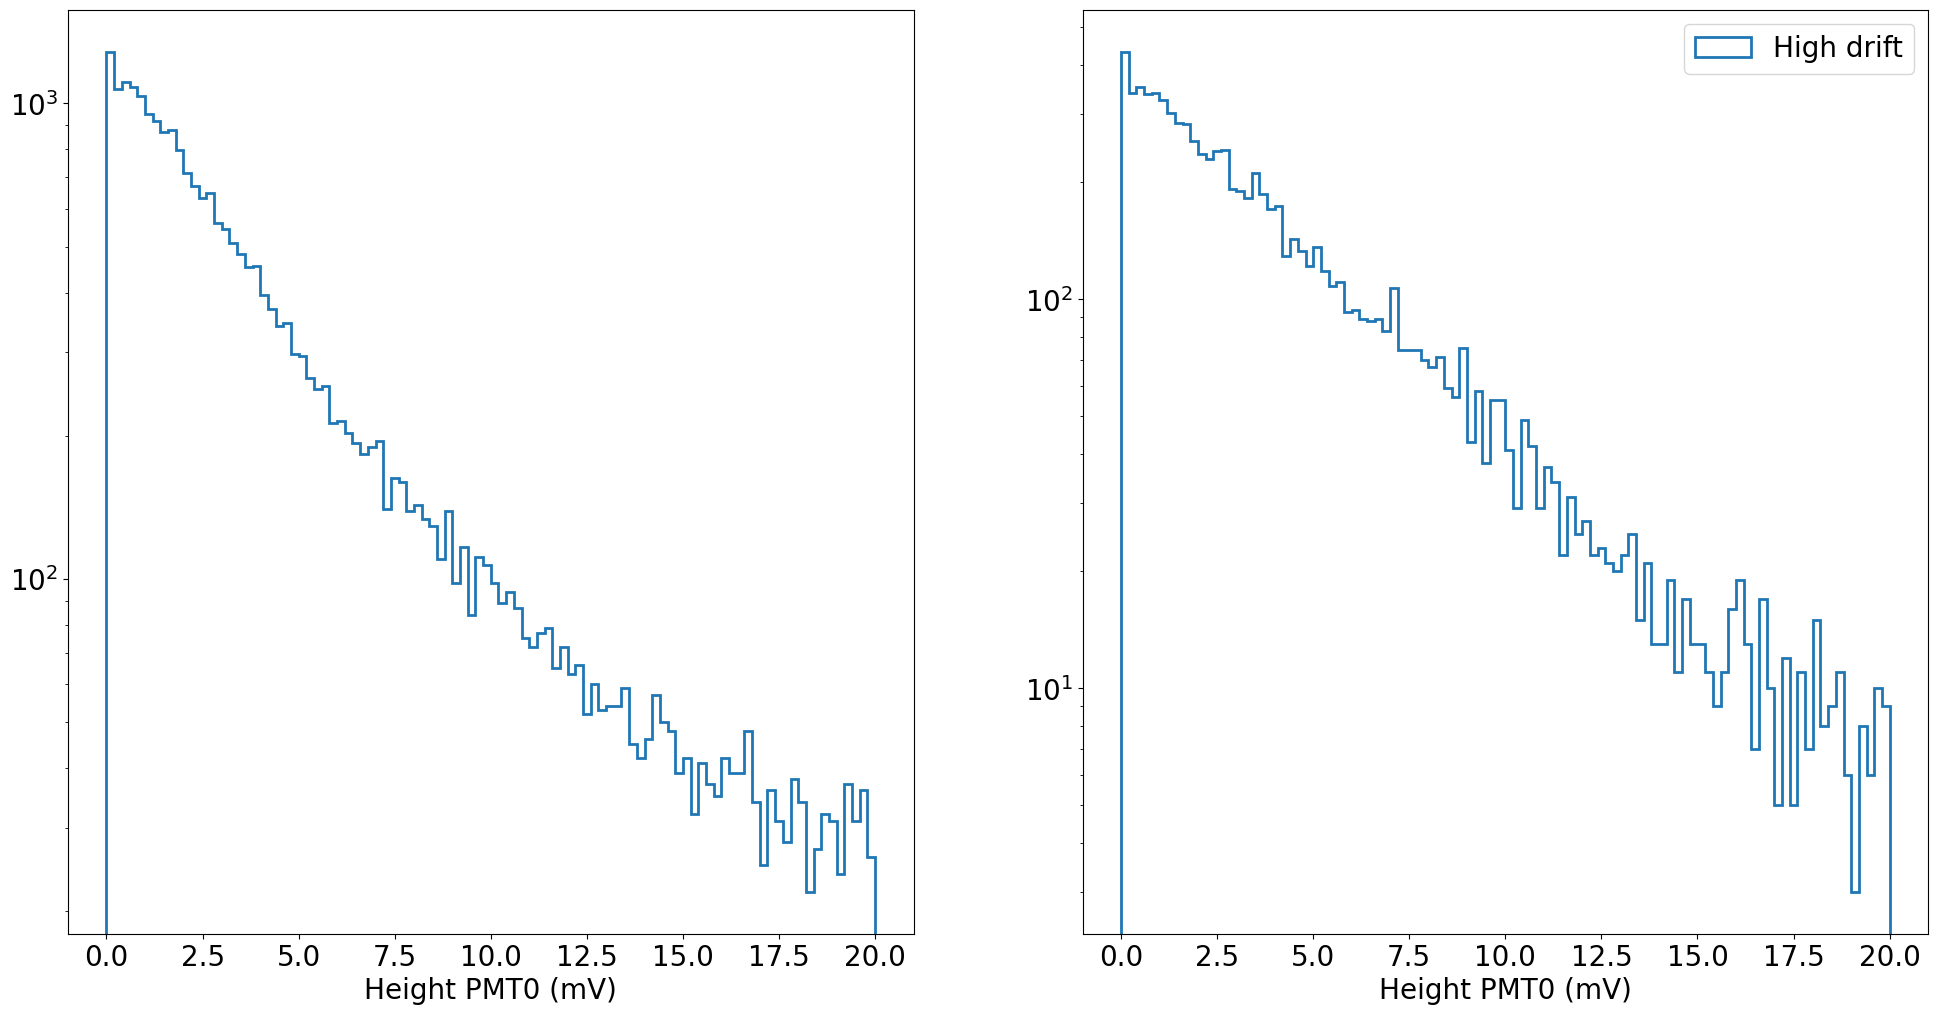

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(0000, 20, 101)
normed = False
var    = 's1_energy'
sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 & sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
#sel1 = sel1 & sel_r_1

axes[0].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);

axes[1].hist(data_1_s2[var][sel1], enebins, histtype='step', 
         lw=2, weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], label=label_1);

for ax in axes:
    ax.set_xlabel('Height PMT0 (mV)')
    ax.set_yscale('log')
trange = [15500, 18000]
trange = [10000, 18000]
sel_t_1 = coref.in_range(data_1_s2[var], *trange)
plt.legend()

#### XY pos

In [28]:
data_pmt = db.DataPMT('gap', 1)
xpmt = data_pmt.X.values
ypmt = data_pmt.Y.values

In [29]:
sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 & sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
###sel1 = sel1 & sel_r_1

In [30]:
len(data_1_s2[sel1])/3600

9.805555555555555

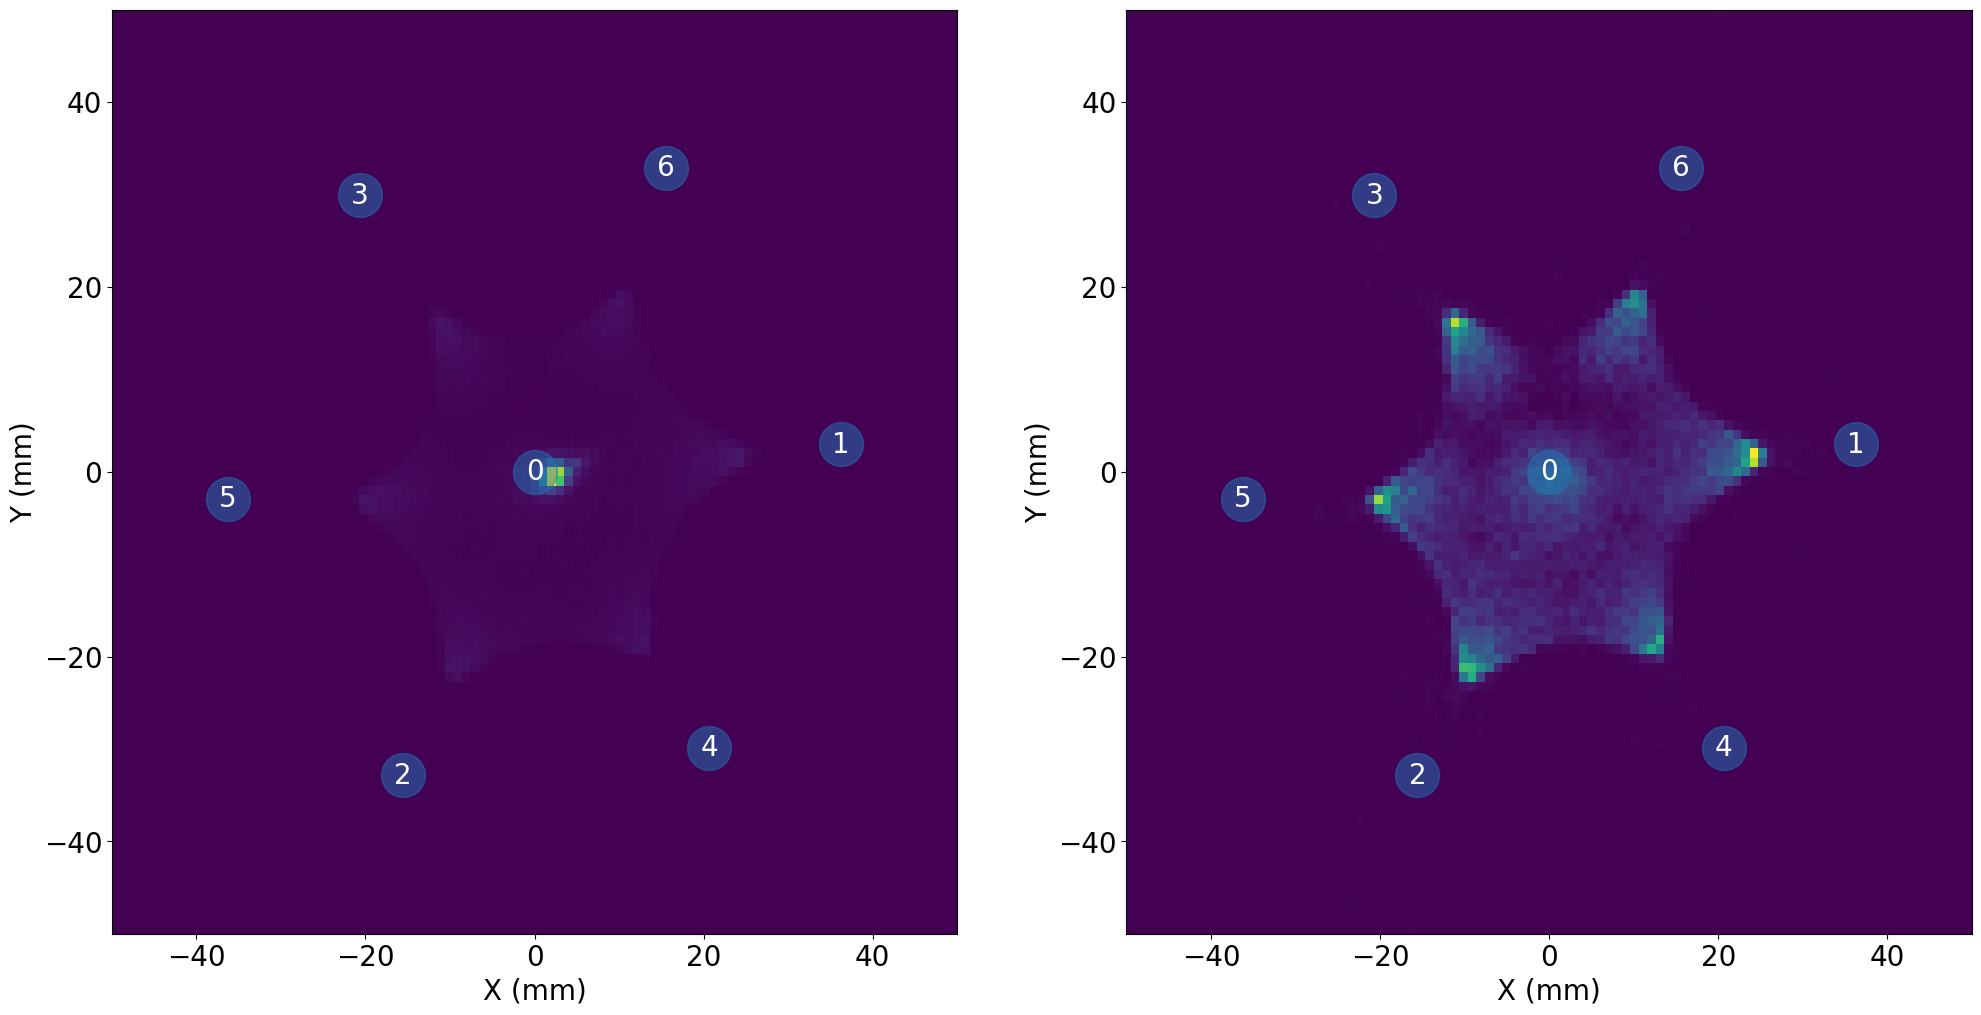

In [38]:
xybins = np.linspace(-50, 50, 100)

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

axes[0].hist2d(data_1_s2.x, data_1_s2.y, xybins)#, norm = colors.LogNorm());
axes[1].hist2d(data_1_s2[sel1].x, data_1_s2[sel1].y, xybins);

for ax in axes:
    ax.scatter(xpmt, ypmt, s=1000, alpha=0.5)
    for i in range(7):
        ax.text(xpmt[i], ypmt[i], f'{i}', c='w', horizontalalignment='center', verticalalignment='center')
        
for ax in axes:
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')

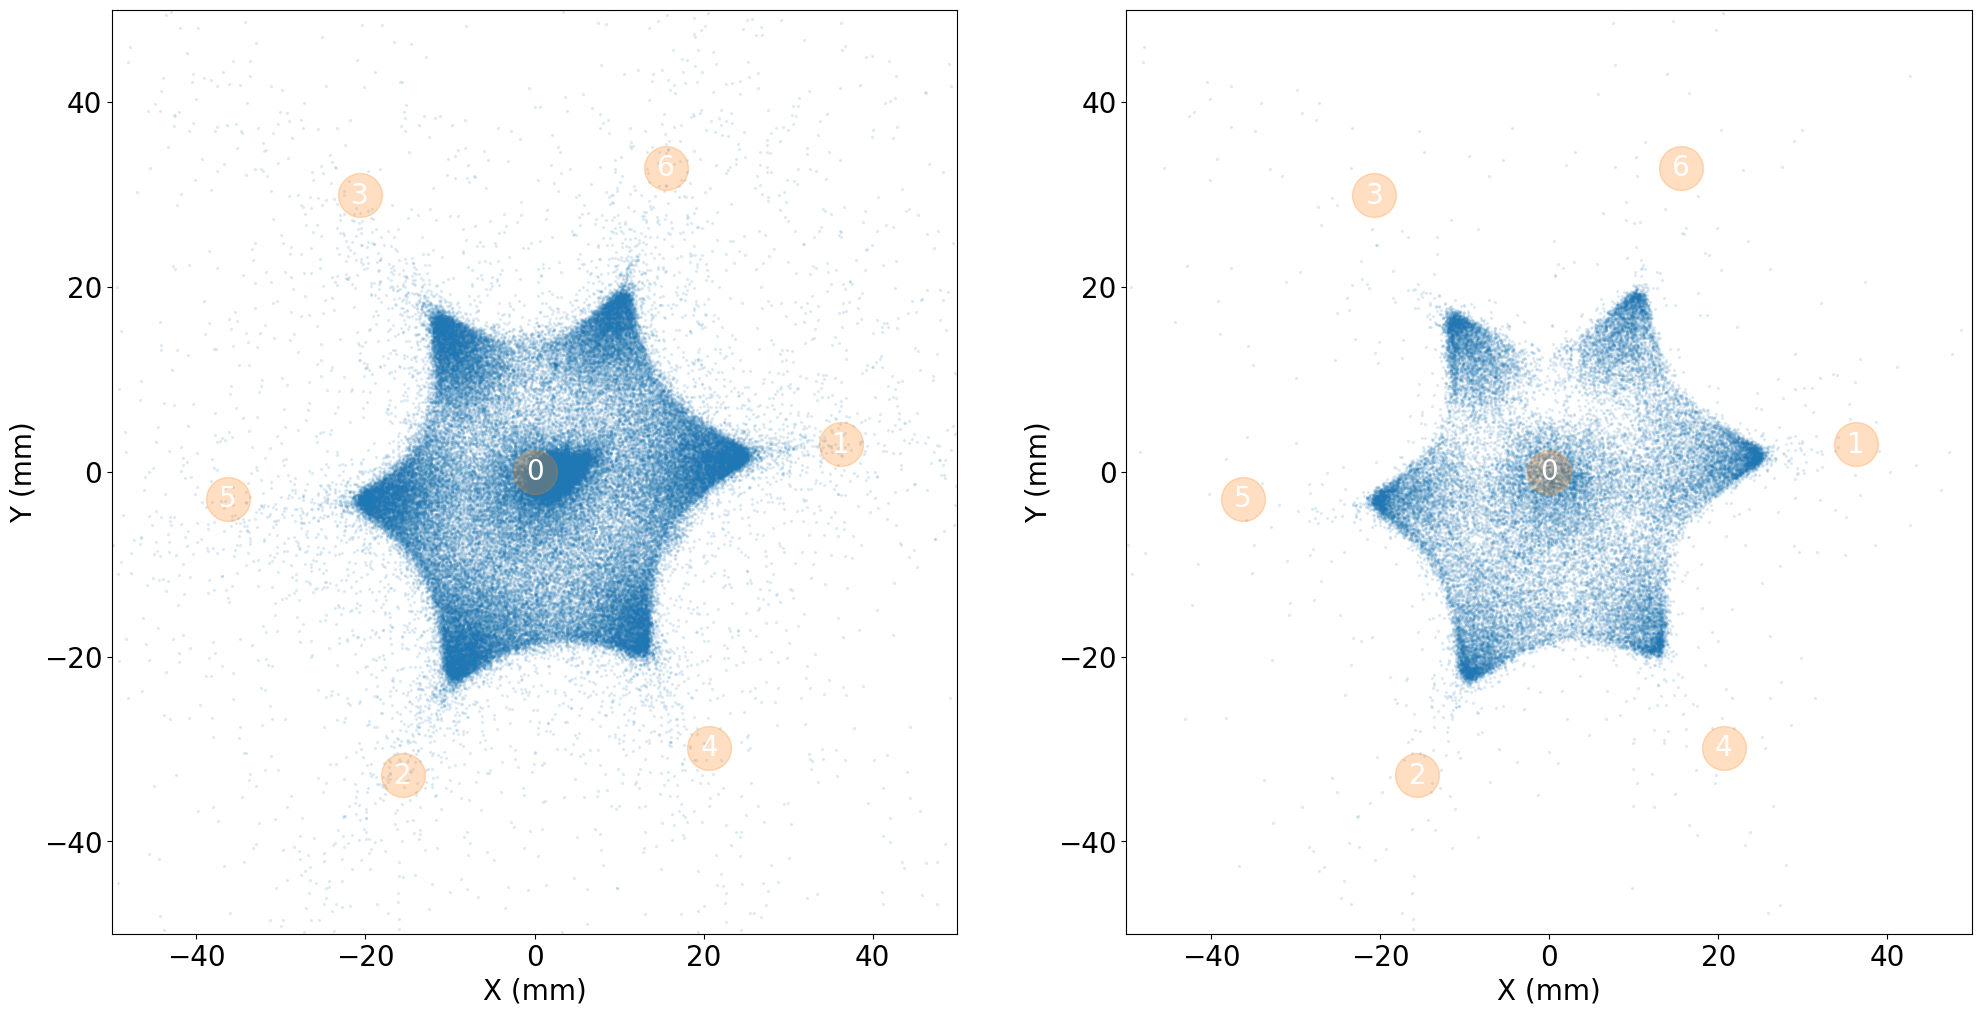

In [37]:
xybins = np.linspace(-50, 50, 100)

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

axes[0].scatter(data_1_s2.x, data_1_s2.y, s=2, alpha=0.1);
axes[1].scatter(data_1_s2[sel1].x, data_1_s2[sel1].y, s=2, alpha=0.1);

for ax in axes:
    ax.scatter(xpmt, ypmt, s=1000, alpha=0.25)
    ax.set_xlim(xybins[0], xybins[-1])
    ax.set_ylim(xybins[0], xybins[-1])
    #ax.legend()
    for i in range(7):
        ax.text(xpmt[i], ypmt[i], f'{i}', c='w', horizontalalignment='center', verticalalignment='center')
      
xrange = [9, 14]
yrange = [-8.5, -13.5]

for ax in axes:
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
#axes[1].axvspan(*xrange, alpha=0.2)
#axes[1].axhspan(*yrange, alpha=0.2)

In [43]:
rmax = 2
sel_r_1 = np.sqrt(data_1_s2.x**2 + data_1_s2.y**2) < rmax
sel_xy_1 = coref.in_range(data_1_s2.x, *xrange) & coref.in_range(data_1_s2.y, *yrange[::-1])

2.6638888888888888


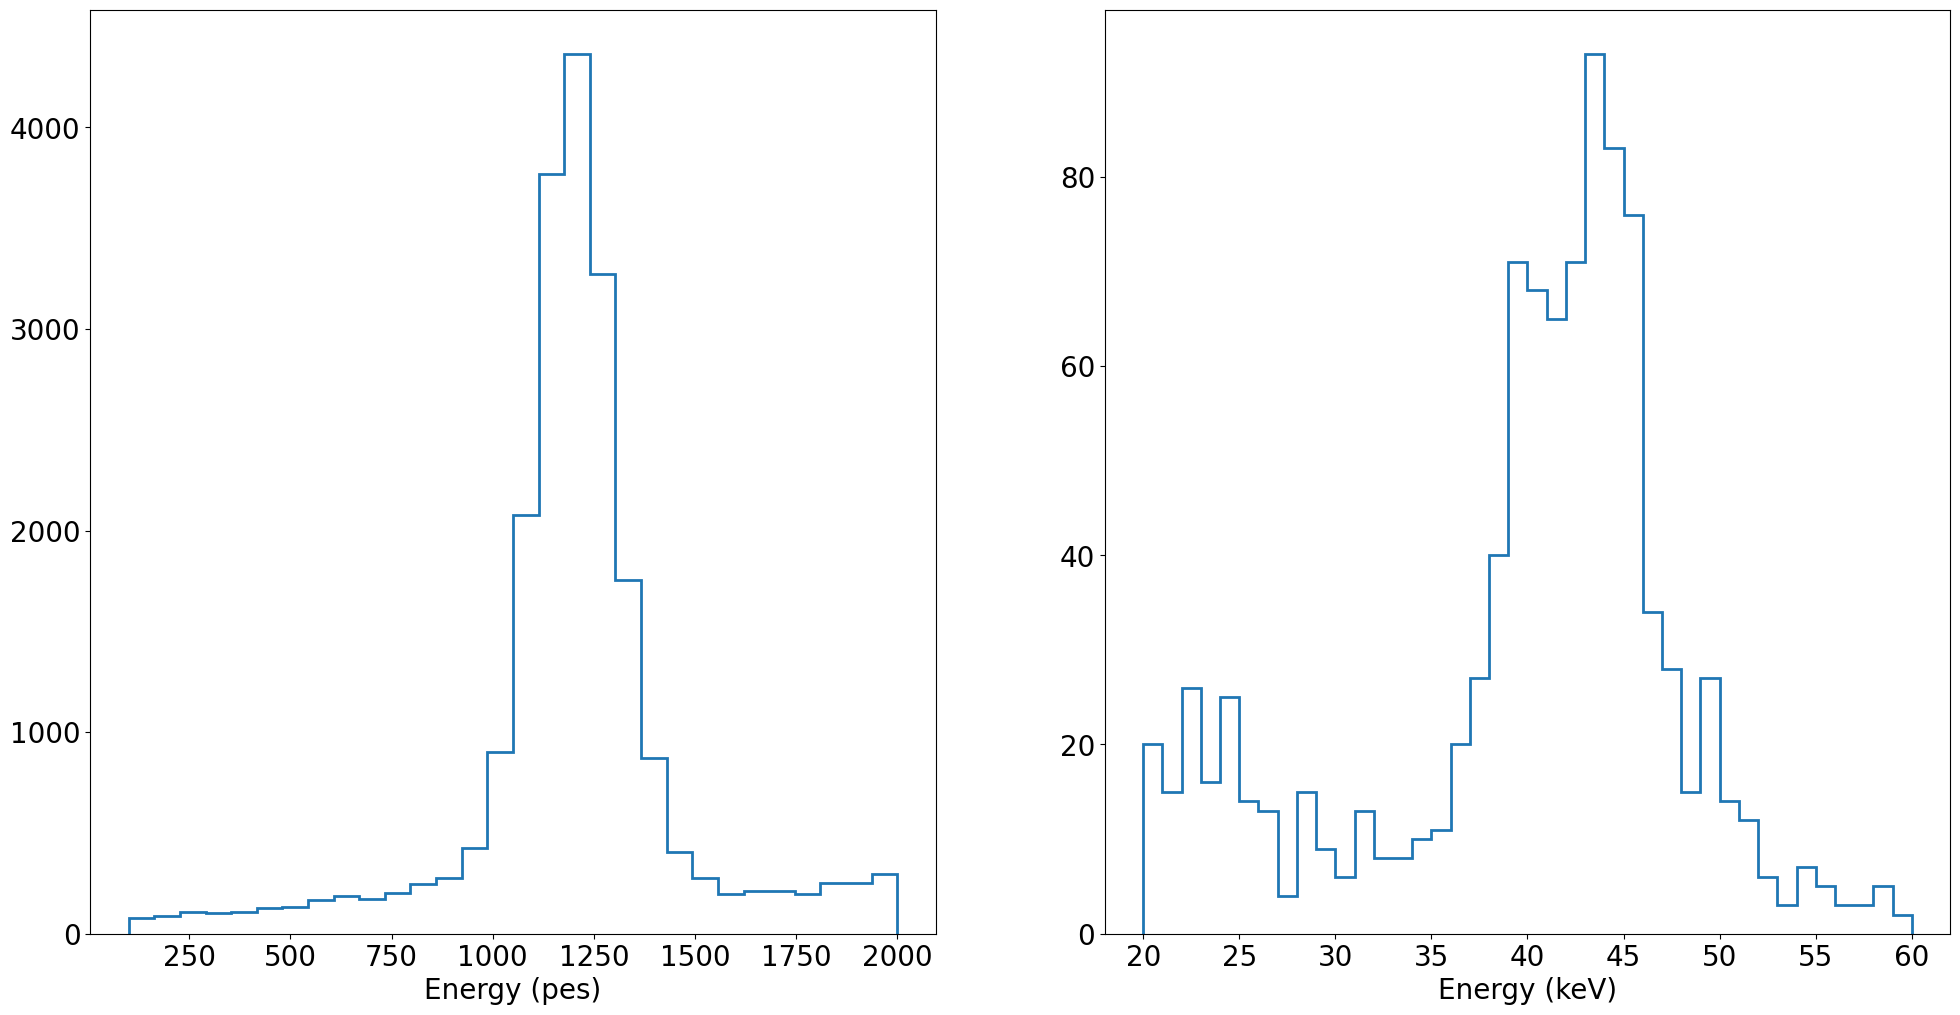

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(100, 2000, 31)
#enebins = np.linspace(0000, 400, 251)
normed = False
var    = 'energy'


sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 #& sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
sel1 = sel1 & sel_r_1
print(len(data_1_s2[sel1])/3600)
eref = 5.9
#eref = 41.5

y,x, *_ = axes[0].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);
x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()]/eref
#escale_1 = 525/eref
#escale_1 = 1
#print(x[y.argmax()])
enebins = np.linspace(20, 60, 41)
#enebins = np.linspace(0, 60, 101)
axes[1].hist(data_1_s2[var][sel1]/escale_1, enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2)[sel1] if normed else weights_1_s2[sel1], label=label_1);
#axes[1].hist(data_1_s2[var][sel1], enebins, histtype='step', 
#         lw=2, weights=weights_1_s2/len(data_1_s2)[sel1] if normed else weights_1_s2[sel1], label=label_1);

for ax in axes:
    #ax.set_yscale('log')
    pass
axes[0].set_xlabel('Energy (pes)')
axes[1].set_xlabel('Energy (keV)')

ar_xray   = [2.9, 3.2]
colors    = ['b'] * len(ar_xray)
#al_xray   = [1.5]
#colors   += ['k'] * fe_lines
fe_lines  = [5.9, 6.5]
colors   += ['k'] * len(fe_lines)
cu_lines = [9.4]
colors   += ['r'] * len(cu_lines)

am_lines = [13.9, 17.7, 26.3, 59.6][:3] # From 2212.11515
colors   += ['g'] * len(am_lines)
am_lines2 = [am - 3 for am in am_lines]
colors   += ['olive'] * len(am_lines)
energy_lines = ar_xray  + fe_lines + cu_lines +  am_lines + am_lines2

for color, line in zip(colors, energy_lines):
    #axes[1].axvline(line, c=color, ls='--')
    pass
#erange = [2500, 4500]
#axes[0].axvspan(*erange, alpha=0.2)
#axes[1].axvspan(*erange, alpha=0.2)
sel_e_1 = coref.in_range(data_1_s2[var], *erange)
#len()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


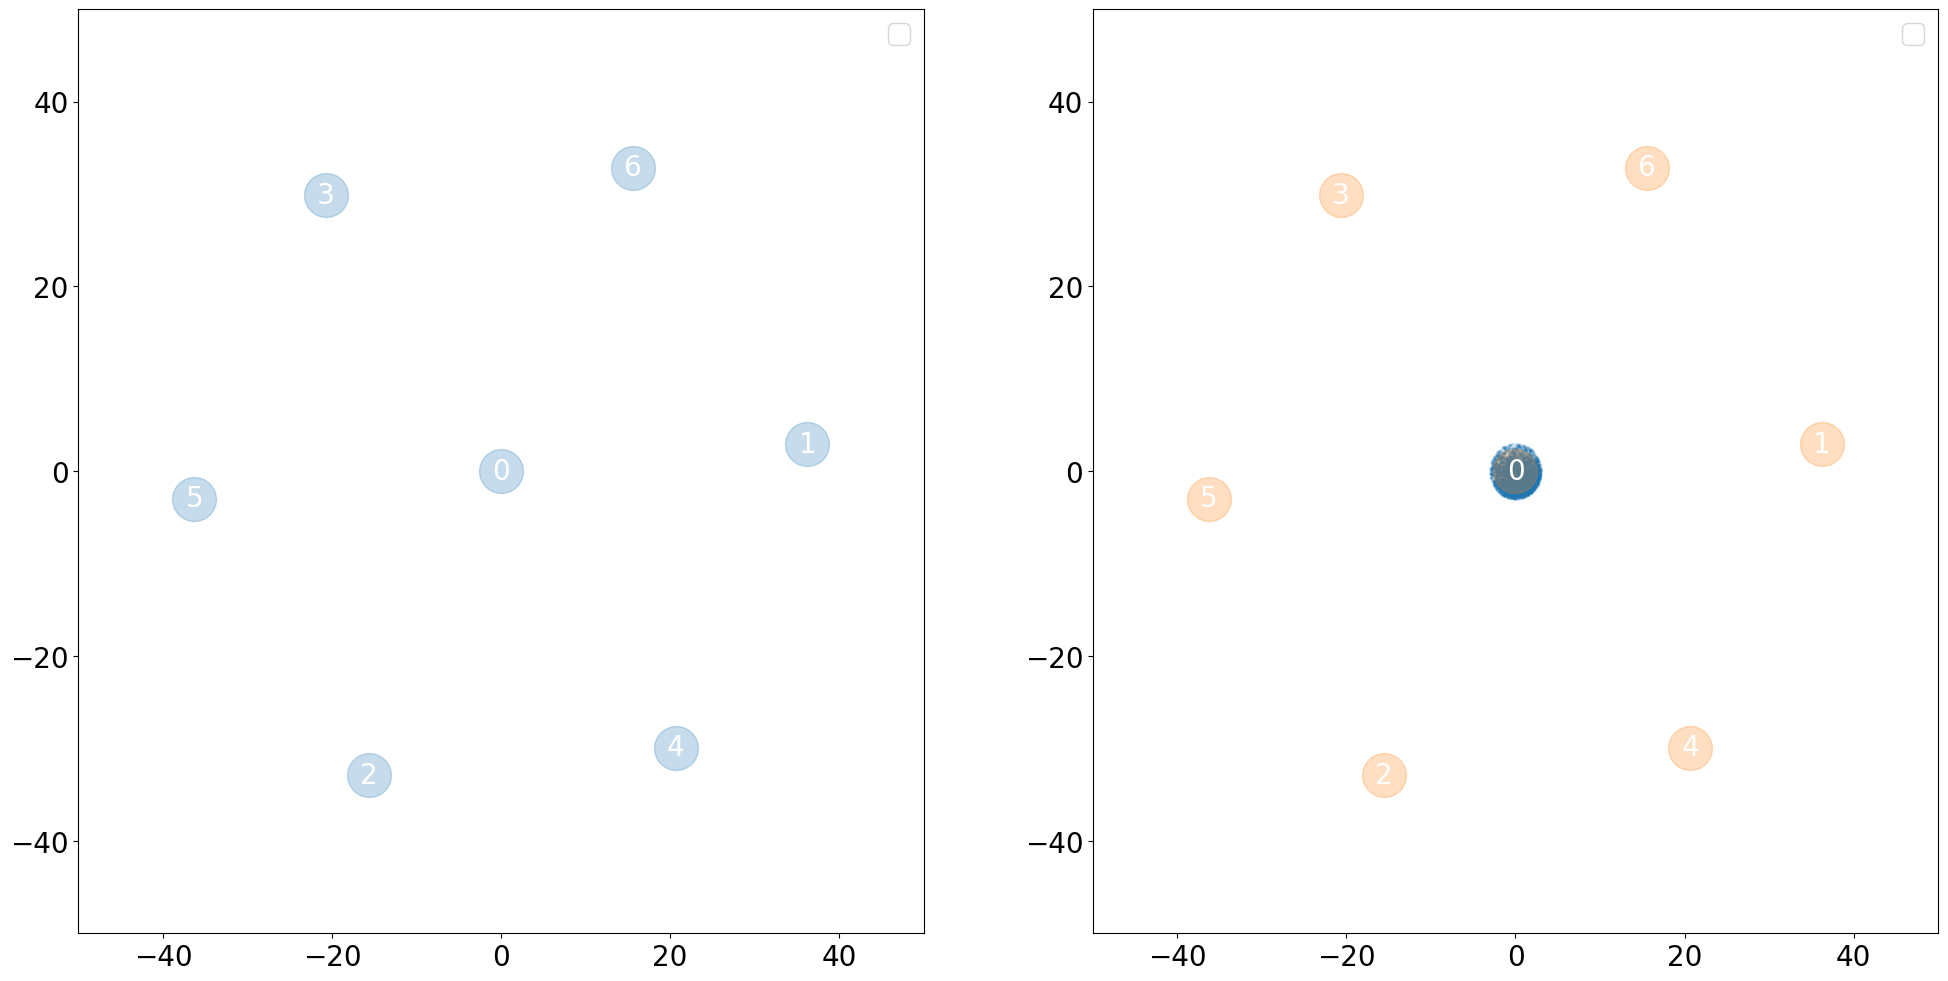

In [30]:
xybins = np.linspace(-50, 50, 100)

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

#axes[0].scatter(data_1_s2.x, data_1_s2.y, s=2, alpha=0.1);
axes[1].scatter(data_1_s2[sel1].x, data_1_s2[sel1].y, s=2, alpha=0.1);

for ax in axes:
    ax.scatter(xpmt, ypmt, s=1000, alpha=0.25)
    ax.set_xlim(xybins[0], xybins[-1])
    ax.set_ylim(xybins[0], xybins[-1])
    ax.legend()
    for i in range(7):
        ax.text(xpmt[i], ypmt[i], f'{i}', c='w', horizontalalignment='center', verticalalignment='center')
      
xrange = [9, 14]
yrange = [-8.5, -13.5]
#axes[1].axvspan(*xrange, alpha=0.2)
#axes[1].axhspan(*yrange, alpha=0.2)

### Energy resolution

In [17]:
fano = 0.15
wi   = 22
data_pmt = db.DataPMT('gap', 1)
pmt_sigma = (data_pmt.Sigma/data_pmt.adc_to_pes).mean()

def get_intrinsic_resolution(energy, fano, wi, det_phot, pmt_sigma):
    fano_term =  fano / (energy/wi)
    det_term  = (1+pmt_sigma**2)/det_phot
    return 235 * np.sqrt(fano_term + det_term)

def el_yield(p, kv):
    return (81*kv/p - 47)*p

E resolution =  46.58%
Intrinsic resolution = 10.706143206267903%
Light collection eff = 0.657%
808.9560817711242


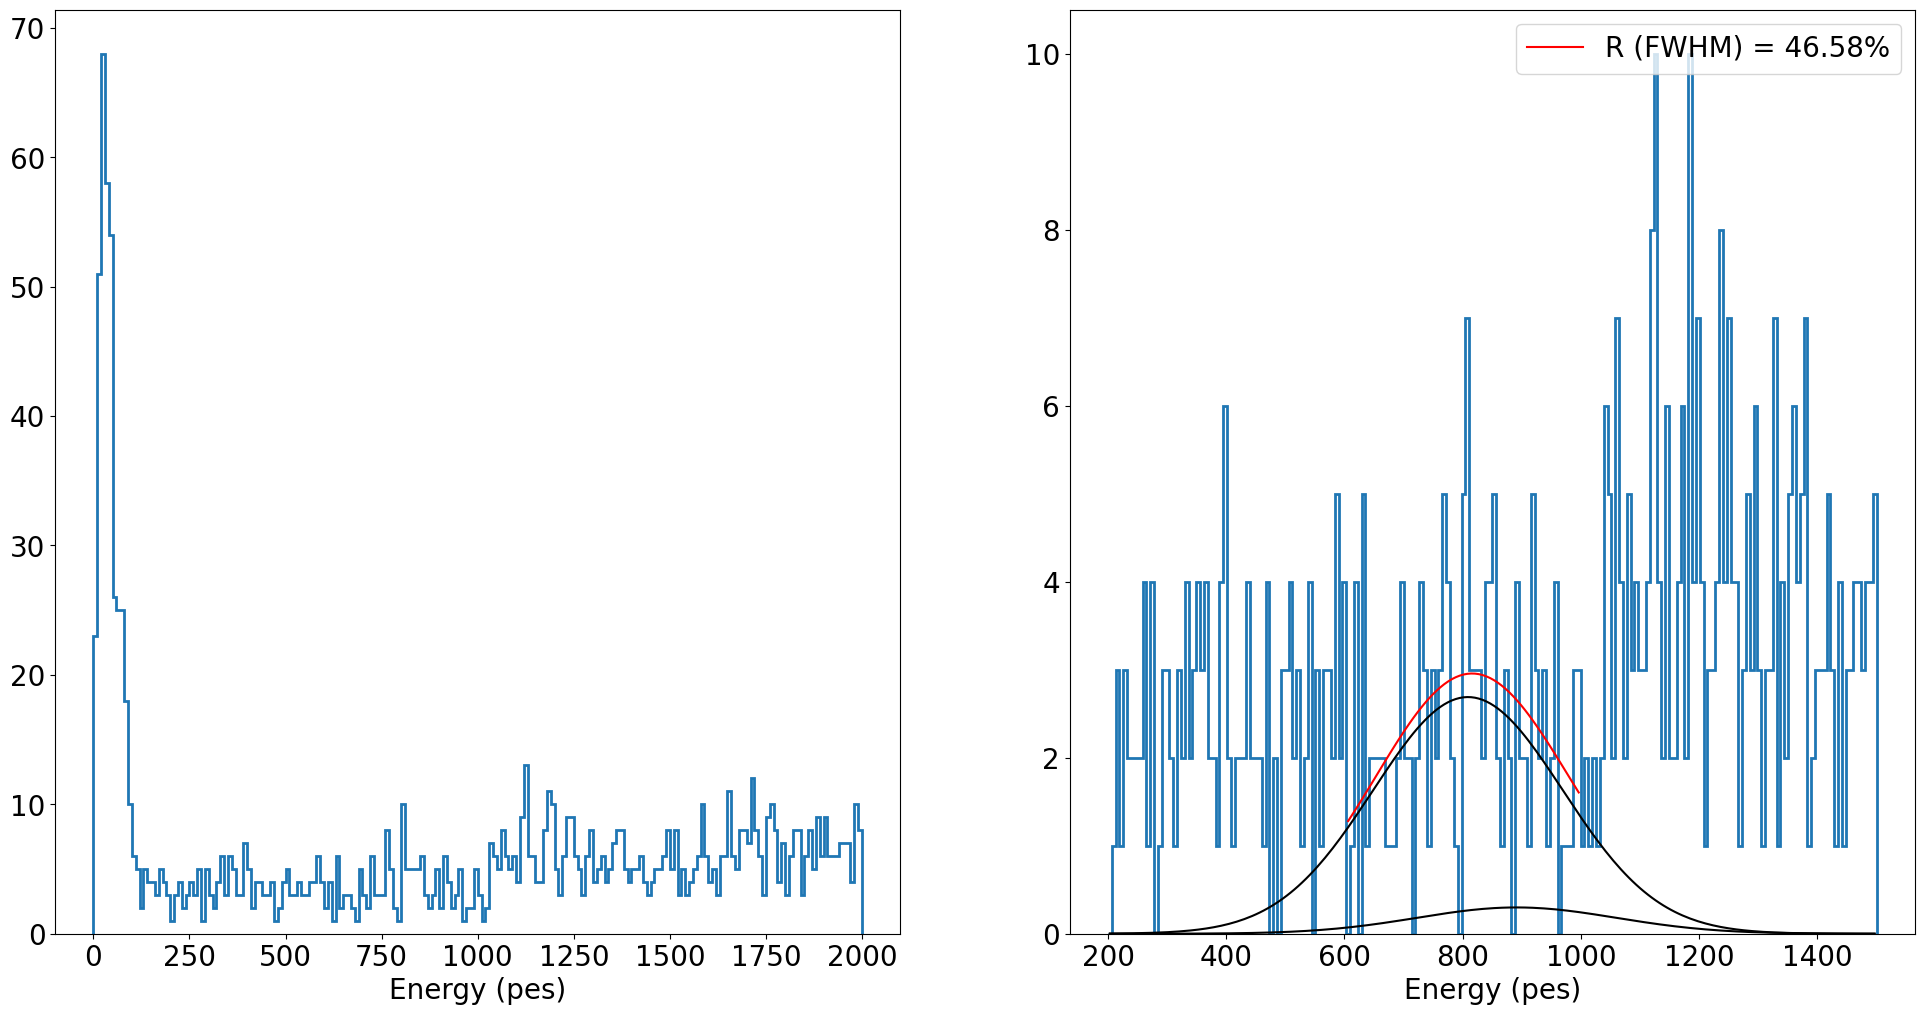

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(0, 2000, 201)
#enebins = np.linspace(0000, 400, 251)
normed = False
var    = 'energy'

eref = 2.9
eref = 5.9

y,x, *_ = axes[0].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2);
x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()]/eref

enebins = np.linspace(200, 1500, 201)
yd, xd, *_ = axes[1].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2);
xd = coref.shift_to_bin_centers(xd)

for ax in axes:
    #ax.set_yscale('log')
    pass

axes[0].set_xlabel('Energy (pes)')
axes[1].set_xlabel('Energy (pes)')


erange = [600, 1000]
#axes[1].axvspan(*erange, alpha=0.2)
sel_e_1 = coref.in_range(data_1_s2[var], *erange)

efit = [600, 1000]
sel_f = coref.in_range(xd, *efit)

centers   = np.array([5.9, 6.5])
int_ratio = np.array([11142, 1299])

mod  = GaussianModel(prefix='g1_')
pars = mod.guess(yd[sel_f], x=xd[sel_f])

for i in range(1, len(centers)):
    g = GaussianModel(prefix=f'g{i+1}_')
    mod += g
    params = g.make_params(center=pars['g1_center'],
                            sigma=pars['g1_sigma'],
                            amplitude=pars['g1_amplitude'])
    params[f'g{i+1}_center'].set(value=pars['g1_center'], vary=True, expr=f'g1_center*{centers[i]/centers[0]}')
    params[f'g{i+1}_sigma'].set(value=pars['g1_center'], vary=True, expr=f'g1_sigma*{np.sqrt(centers[i]/centers[0])}')
    params[f'g{i+1}_amplitude'].set(value=pars['g1_center'], vary=True, expr=f'g1_amplitude*{int_ratio[i]/int_ratio[0]}')
    pars.update(params)

out  = mod.fit(yd[sel_f], pars, x=xd[sel_f])

result =  out.result.params
mu     = [result['g1_center'].value, result['g1_center'].stderr]
sigma  = [result['g1_sigma' ].value, result['g1_sigma' ].stderr]
reso   = sigma[0]/mu[0] * 235
print(f'E resolution =  {reso:.2f}%')
print(f'Intrinsic resolution = {get_intrinsic_resolution(eref*1000, fano, wi, mu[0], pmt_sigma)}%')
#fitf.gauss()
axes[1].plot(xd[sel_f], out.best_fit, '-', c='r', label=f'R (FWHM) = {reso:.2f}%')
axes[1].legend()
for i in range(1, len(centers)+1):
    plt.plot(xd, fitf.gauss(xd, 
                            result[f'g{i}_amplitude'].value, result[f'g{i}_center'].value, result[f'g{i}_sigma'].value),
                            c='k')
    
    
pressure  = 6.6
el_volt   = 9.5
wi        = 22 / 1000 #divide to pass to keV
lyield    = el_yield(pressure, el_volt)
#light_col = 0.0045
light_col = mu[0]/(lyield * eref/wi) * 100
#= lyield * smeared_energy_2/wi * light_col


print(f'Light collection eff = {light_col:.3f}%')
print(mu[0])

In [26]:
300/22*lyield*0.00638

39.95910000000001

In [27]:
get_intrinsic_resolution(eref*1000, fano, wi, mu[0], pmt_sigma)

9.250444320717362

#### Radial dependance

Text(0, 0.5, 'Energy (pes)')

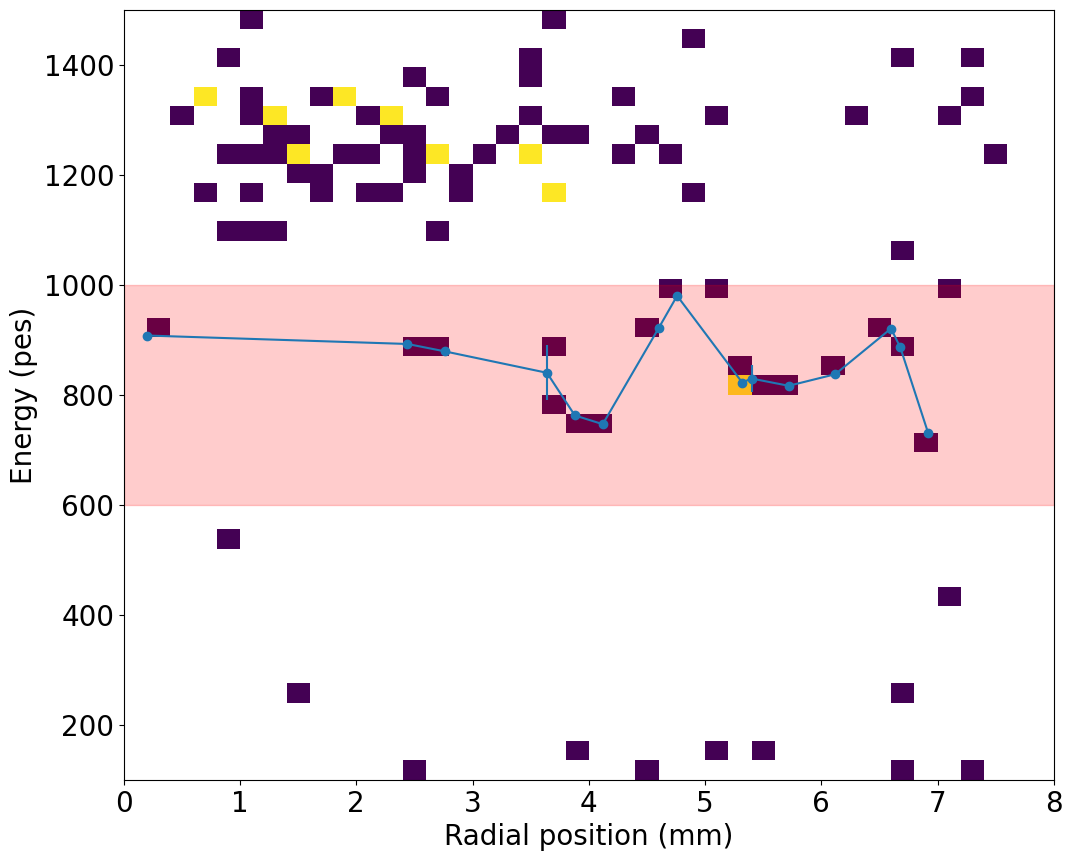

In [29]:
enebins   = np.linspace(100, 1500, 41)
rbins     = np.sqrt(np.linspace(0, 8**2, 41))
rbins     = np.linspace(0, 8, 41)

normed = False
var1   = 'r'
var2   = 'energy'

sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 #& sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
#sel1 = sel1 & sel_r_1

h, x, y, *_ = plt.hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1], [rbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());
rprof = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1], xrange=[rbins[0], rbins[-1]], yrange=erange, nbins=100)
plt.errorbar(rprof[0], rprof[1], yerr=rprof[2], marker='o')

rrange = [0, 3]
sel_r_1 = coref.in_range(data_1_s2[var1], *rrange)

plt.axhspan(*erange, alpha=0.2, color='r')
plt.xlabel('Radial position (mm)')
plt.ylabel('Energy (pes)')

Text(0, 0.5, 'Energy (pes)')

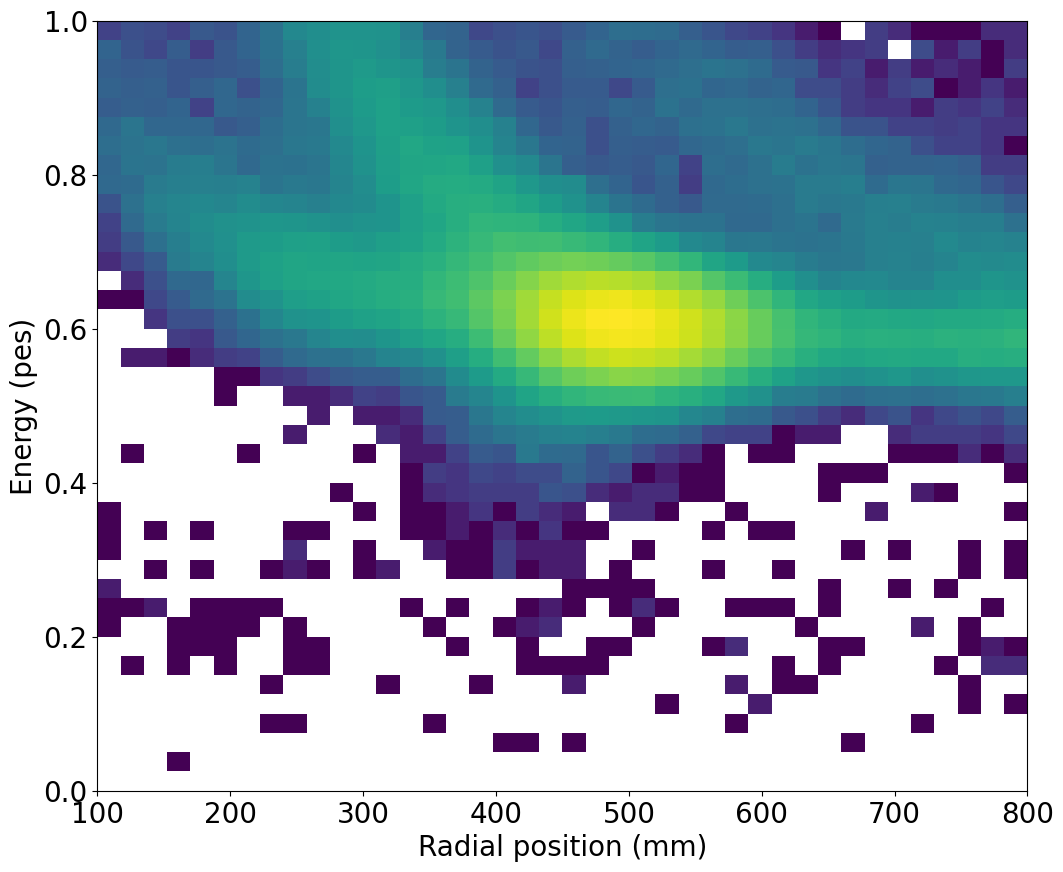

In [51]:
enebins   = np.linspace(0, 1, 41)
rbins     = np.sqrt(np.linspace(0, 8**2, 41))
rbins     = np.linspace(100, 800, 41)

normed = False
var1   = 'energy'
var2   = 'e_pmt0'
var3   = 'energy'

sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 #& sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
#sel1 = sel1 & sel_r_1

h, x, y, *_ = plt.hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1]/data_1_s2[var3][sel1], [rbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());
rprof = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1], xrange=[rbins[0], rbins[-1]], yrange=erange, nbins=100)
plt.errorbar(rprof[0], rprof[1], yerr=rprof[2], marker='o')

rrange = [0, 3]
sel_r_1 = coref.in_range(data_1_s2[var1], *rrange)

plt.axhspan(*erange, alpha=0.2, color='r')
plt.xlabel('Radial position (mm)')
plt.ylabel('Energy (pes)')

#### Width dependance

In [30]:
import scipy.interpolate as interpolate

def find_nearest_id(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

KeyError: 'width'

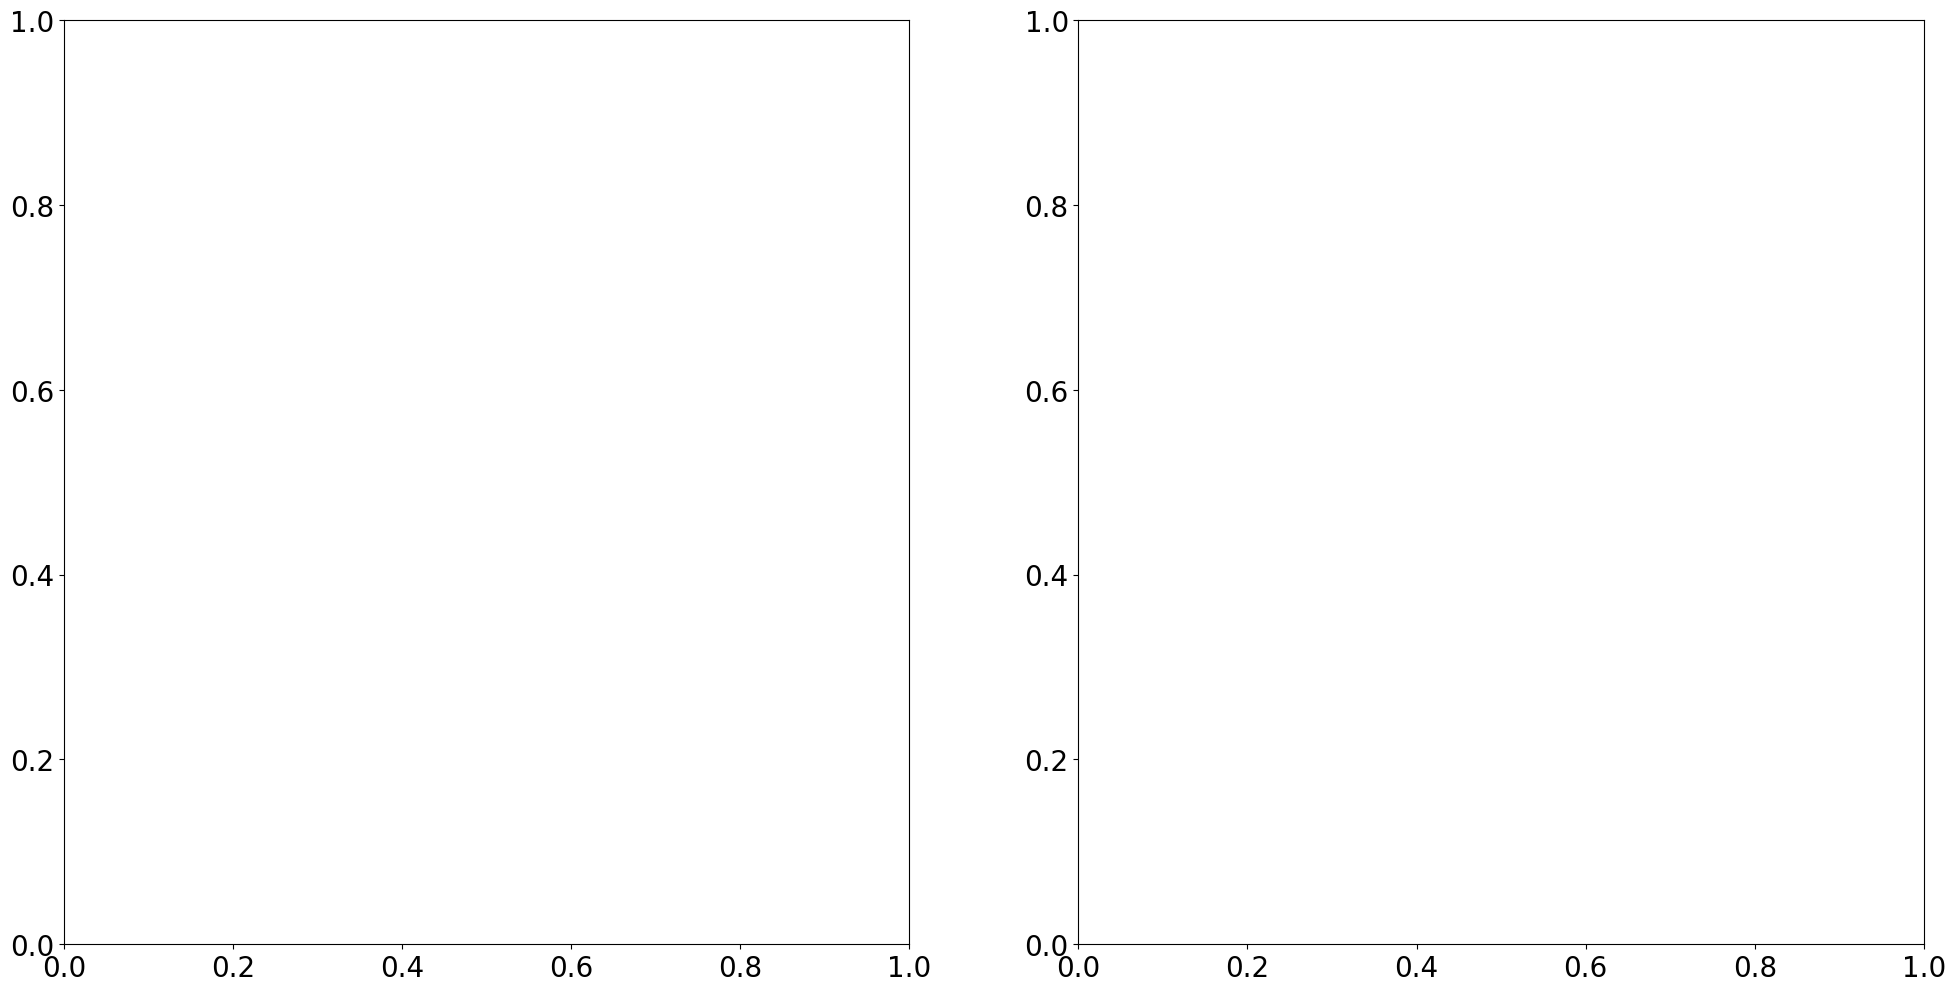

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins   = np.linspace(200, 1000, 41)
wbins     = np.linspace(0, 30000, 101)

normed = False
var1   = 'width'
var2   = 'energy'

sel1 = np.full(len(data_1_s2), True)

#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
#sel1 = sel1 & sel_r_1

h, x, y, *_ = axes[0].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1], [wbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

#sel1 = sel1 & sel_e_1 
wprof = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1], xrange=[wbins[0], wbins[-1]], yrange=erange, nbins=100)
axes[0].errorbar(wprof[0], wprof[1], yerr=wprof[2], marker='o')

wrange = [15e3, 17e3]
sel_w_1 = coref.in_range(data_1_s2[var1], *wrange)

xref  = 15e3
yref  = wprof[1][find_nearest_id(wprof[0], xref)]
wcorr = interpolate.interp1d(wprof[0], wprof[1]/yref, kind='nearest', fill_value='extrapolate')


axes[0].axhspan(*erange, alpha=0.2, color='r')
for ax in axes:
    ax.set_xlabel('S2 width (ns)')
    ax.set_ylabel('Energy (pes)')
    
h, x, y, *_ = axes[1].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1] / wcorr(data_1_s2[var1][sel1]), [wbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

wprof_c = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1]/ wcorr(data_1_s2[var1][sel1]), xrange=[wbins[0], wbins[-1]], yrange=erange, nbins=100)
axes[1].errorbar(wprof_c[0], wprof_c[1], yerr=wprof_c[2], marker='o')


#### Height dependance

<ErrorbarContainer object of 3 artists>

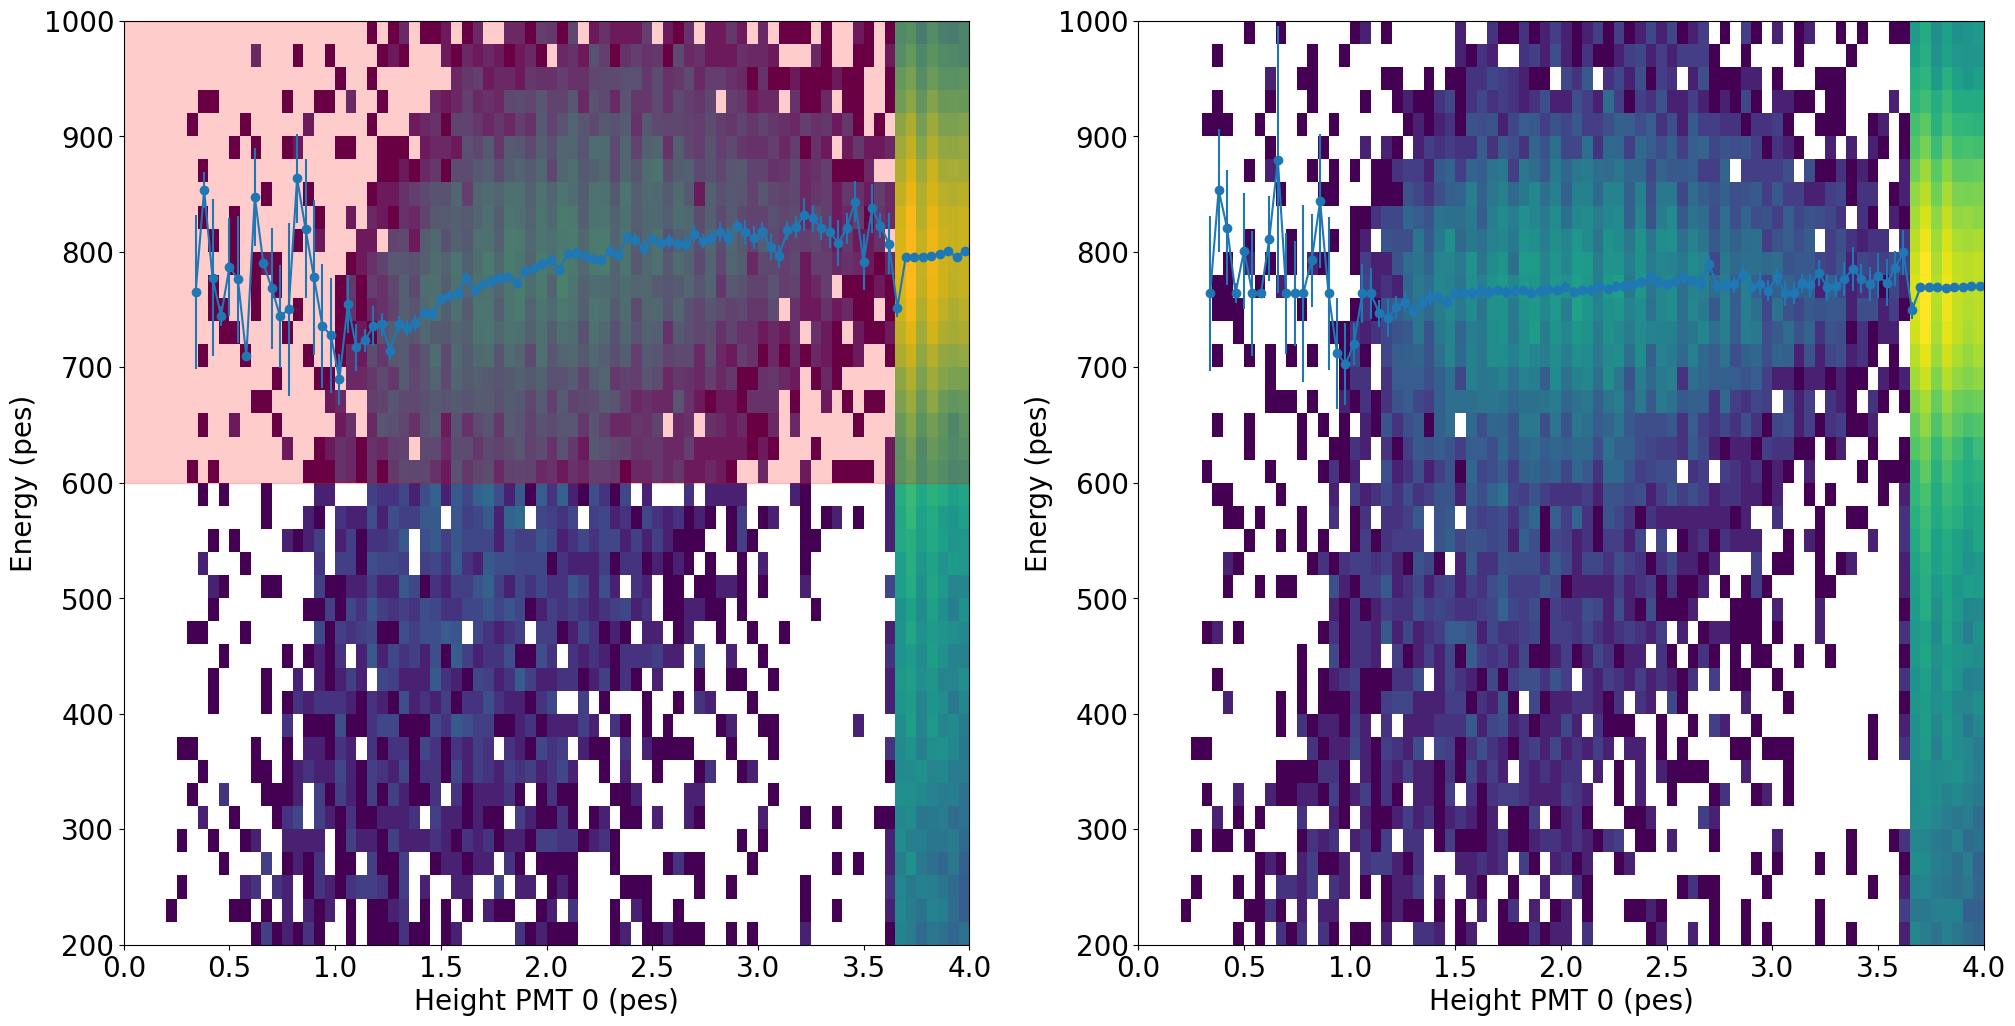

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins   = np.linspace(200, 1000, 41)
hbins     = np.linspace(0, 4., 81)

normed = False
var1   = 'h_pmt2'
var2   = 'energy'

sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 #& sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
#sel1 = sel1 & sel_r_1

h, x, y, *_ = axes[0].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1], [hbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

hprof = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1], xrange=[hbins[0], hbins[-1]], yrange=erange, nbins=100)
axes[0].errorbar(hprof[0], hprof[1], yerr=hprof[2], marker='o')

xref  = 1.6
yref  = hprof[1][find_nearest_id(hprof[0], xref)]
hcorr = interpolate.interp1d(hprof[0], hprof[1]/yref, kind='nearest', fill_value='extrapolate')


hrange = [1.6, 1.7]
sel_h_1 = coref.in_range(data_1_s2[var1], *hrange)

axes[0].axhspan(*erange, alpha=0.2, color='r')
for ax in axes:
    ax.set_xlabel('Height PMT 0 (pes)')
    ax.set_ylabel('Energy (pes)')

h, x, y, *_ = axes[1].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1] / hcorr(data_1_s2[var1][sel1]), [hbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

hprof_c = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1]/ hcorr(data_1_s2[var1][sel1]), xrange=[hbins[0], hbins[-1]], yrange=erange, nbins=100)
axes[1].errorbar(hprof_c[0], hprof_c[1], yerr=hprof_c[2], marker='o')


#### Ratio dependance

In [32]:
data_1_s2['pmt_0_ratio'] = data_1_s2['e_pmt0']/data_1_s2['energy']

<ErrorbarContainer object of 3 artists>

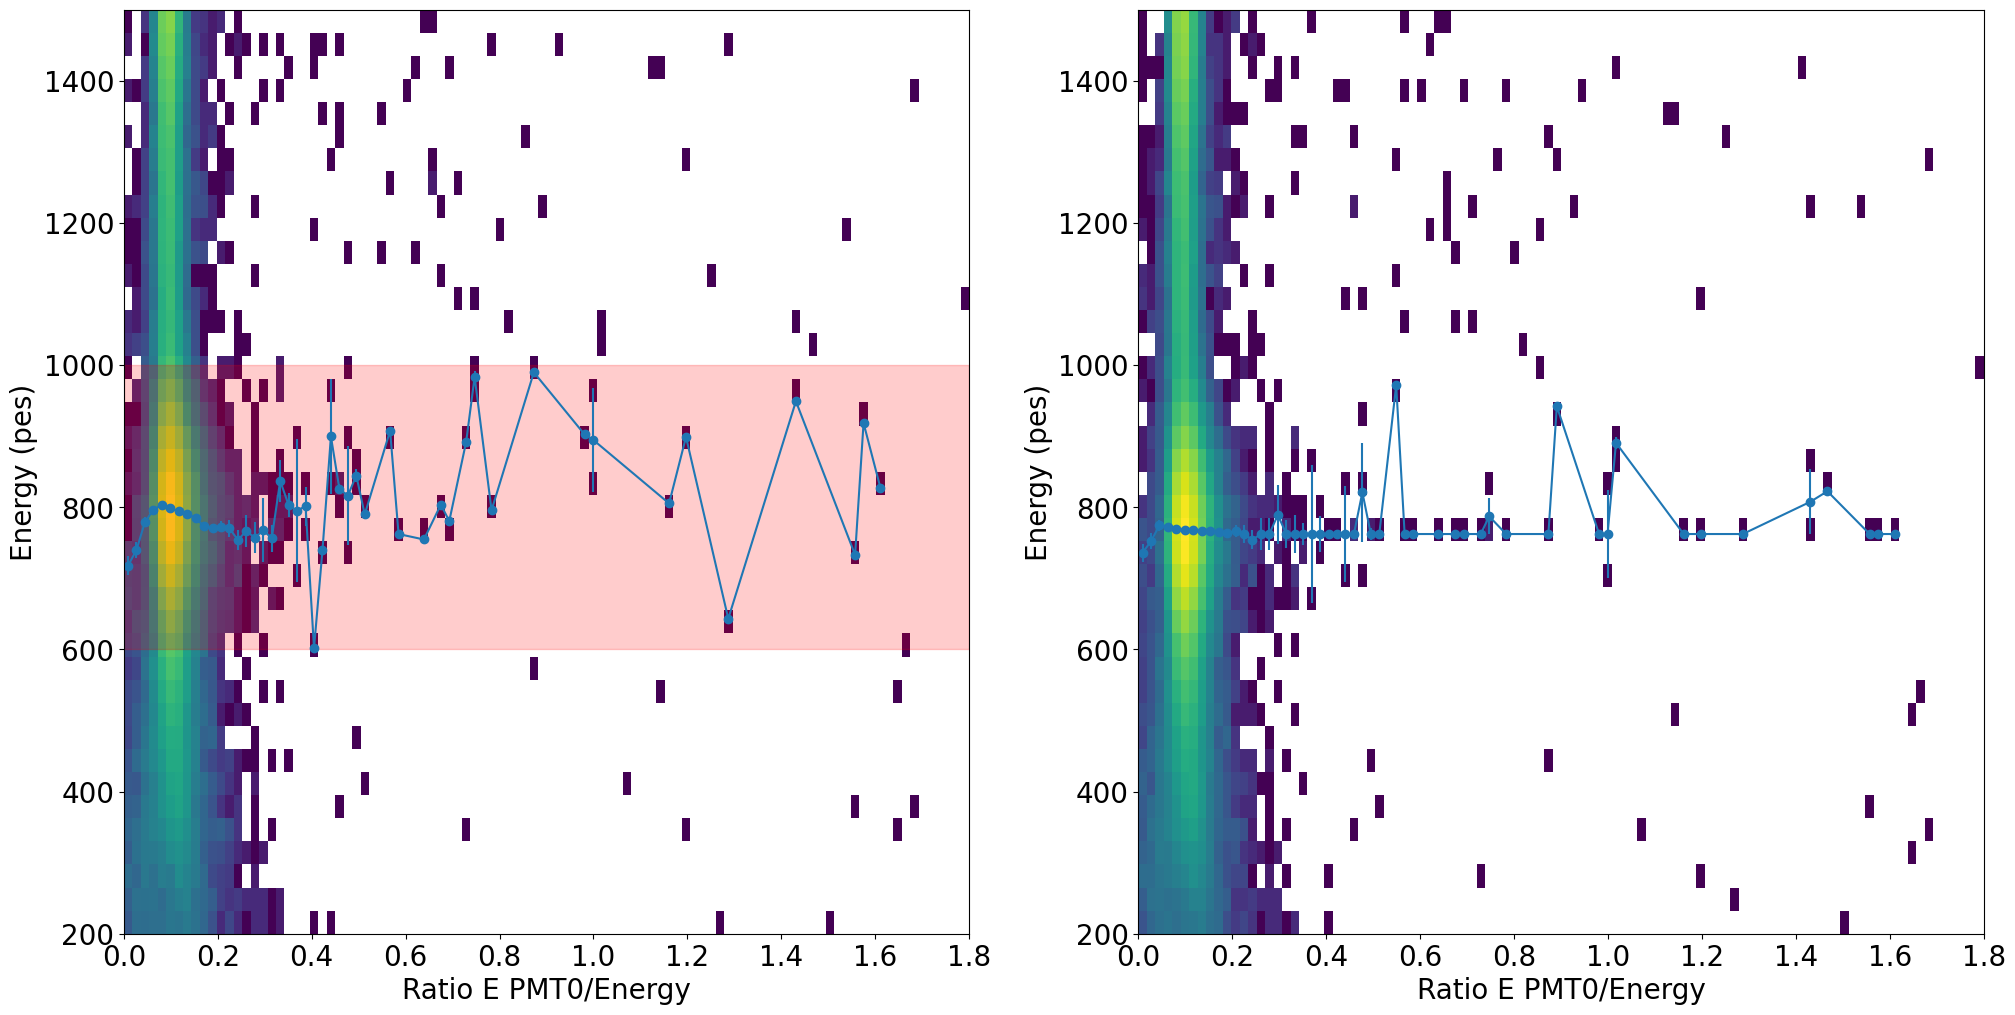

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins   = np.linspace(200, 1500, 41)
ratiobins     = np.linspace(0., 1.8, 101)
#ratiobins     = np.linspace(0., 0.3, 81)

normed = False
var1   = 'pmt_0_ratio'
var2   = 'energy'

sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 #& sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
#sel1 = sel1 & sel_r_1

h, x, y, *_ = axes[0].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1], [ratiobins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

ratioprof = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1], xrange=[ratiobins[0], ratiobins[-1]], yrange=erange, nbins=100)
axes[0].errorbar(ratioprof[0], ratioprof[1], yerr=ratioprof[2], marker='o')

xref  = 0.58
yref  = ratioprof[1][find_nearest_id(ratioprof[0], xref)]
ratiocorr = interpolate.interp1d(ratioprof[0], ratioprof[1]/yref, kind='nearest', fill_value='extrapolate')


ratiorange = [0.5, 0.7]
sel_ratio_1 = coref.in_range(data_1_s2[var1], *ratiorange)

axes[0].axhspan(*erange, alpha=0.2, color='r')
for ax in axes:
    ax.set_xlabel('Ratio E PMT0/Energy')
    ax.set_ylabel('Energy (pes)')

h, x, y, *_ = axes[1].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1] / ratiocorr(data_1_s2[var1][sel1]), [ratiobins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

ratioprof_c = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1]/ ratiocorr(data_1_s2[var1][sel1]), xrange=[ratiobins[0], ratiobins[-1]], yrange=erange, nbins=100)
axes[1].errorbar(ratioprof_c[0], ratioprof_c[1], yerr=ratioprof_c[2], marker='o')

#### Time dependance

In [36]:
data_1_s2['time'] = (data_1_s2['timestamp'] - data_1_s2['timestamp'].min())*8e-9/60

(array([2341., 1117.,  985., 2520., 2724., 3236., 3487., 3777., 3831.,
        3846., 3594., 3927., 4241., 3770., 3751., 3921., 3775., 3574.,
        3001., 2594., 3403., 3186., 3089., 4024., 3371., 3157., 4316.,
        4646., 3398., 3087., 3624., 3493., 3589., 3594., 4130., 3611.,
        3590., 3577., 3259., 3321., 3637., 3648., 3392., 2384., 2608.,
        2544., 2808., 3008., 3086., 3058., 3122., 3602., 3340., 2976.,
        2455., 2094., 2447., 2864., 2996., 3056., 3145., 3251., 3861.,
        3636., 3243., 2536., 2584., 3688., 3709., 3203., 2803., 3477.,
        3771., 3381., 3224., 3560., 3341., 3117., 2665., 3209.]),
 array([ 0.        ,  1.23508156,  2.47016312,  3.70524468,  4.94032625,
         6.17540781,  7.41048937,  8.64557093,  9.88065249, 11.11573405,
        12.35081562, 13.58589718, 14.82097874, 16.0560603 , 17.29114186,
        18.52622342, 19.76130499, 20.99638655, 22.23146811, 23.46654967,
        24.70163123, 25.93671279, 27.17179435, 28.40687592, 29.64195748,
 

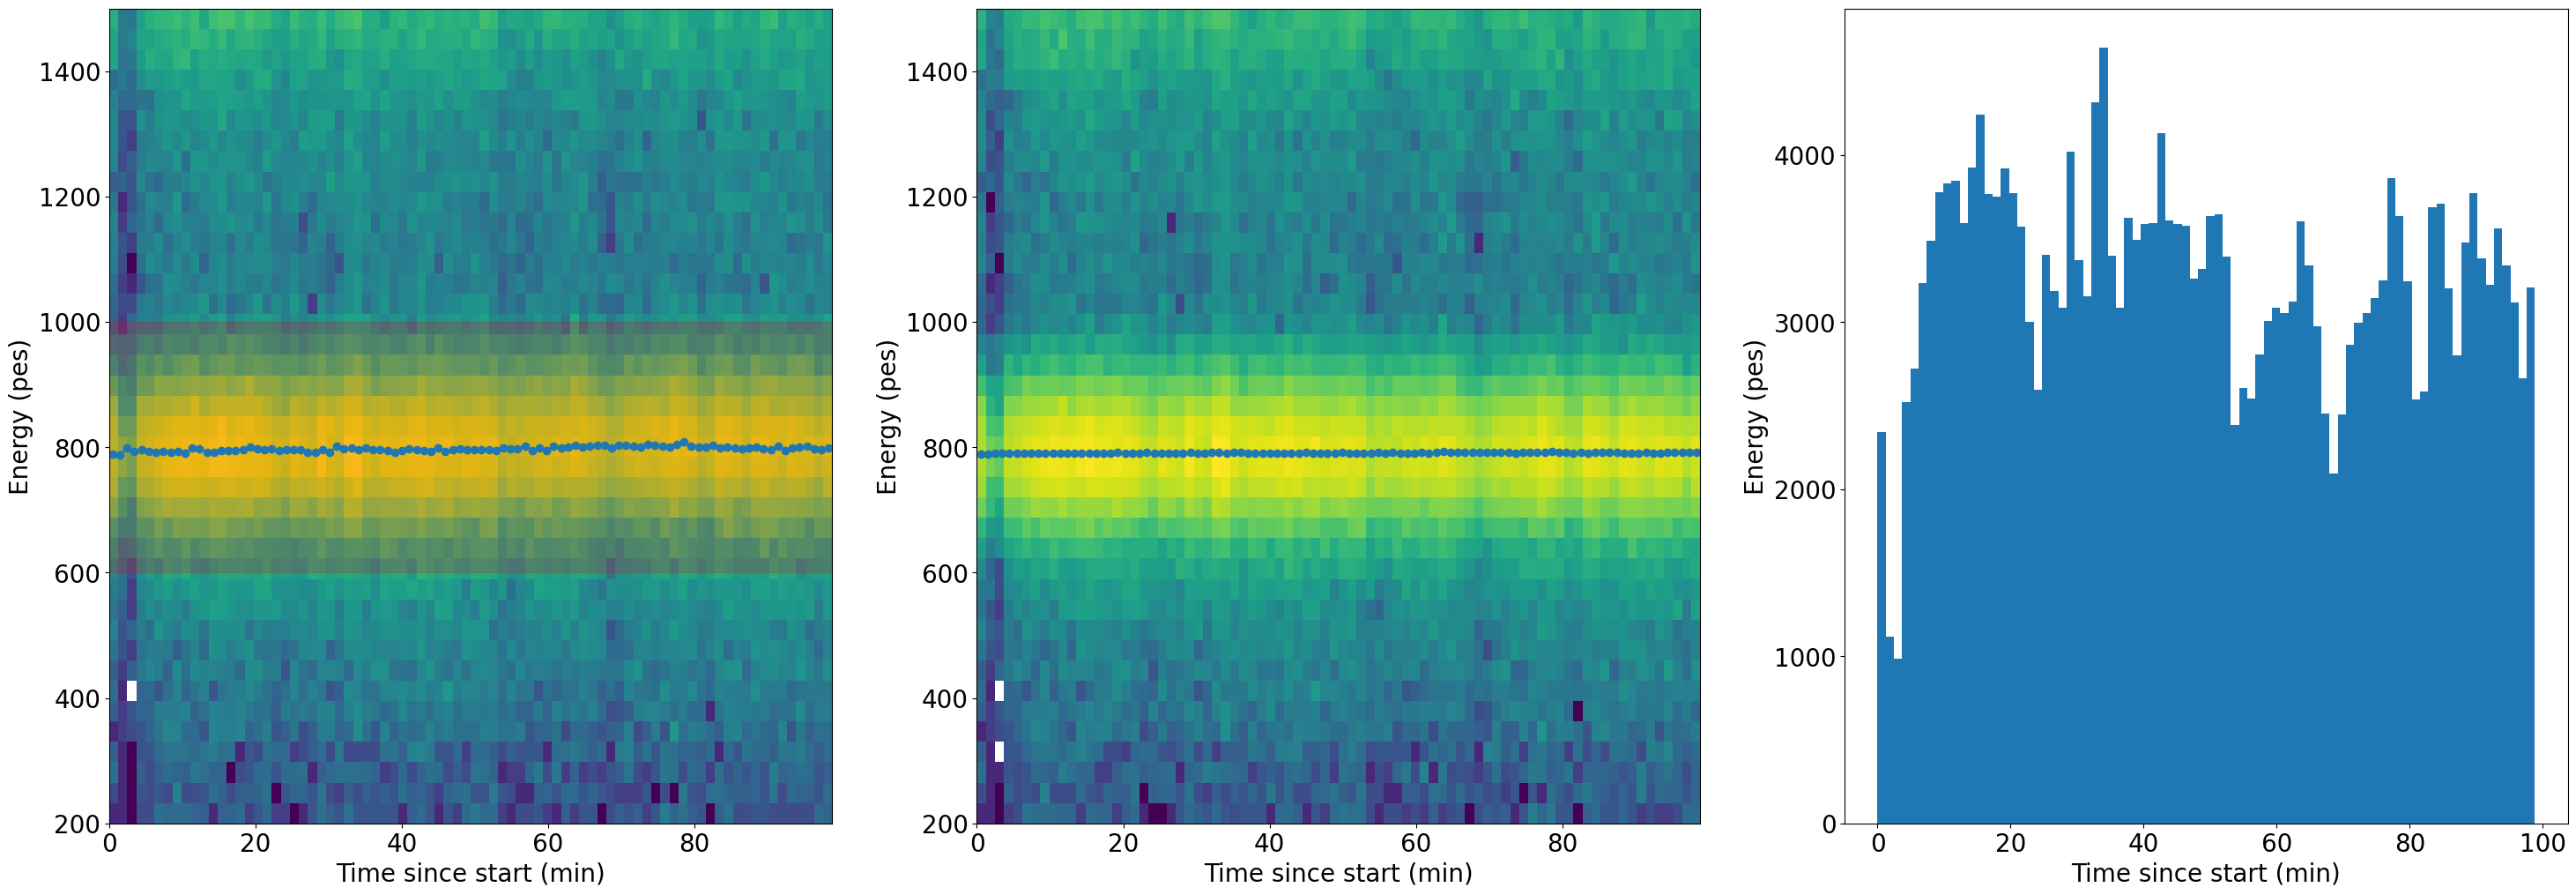

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(36, 12))

enebins   = np.linspace(200, 1500, 41)
tbins     = np.linspace(data_1_s2['time'].min(), data_1_s2['time'].max(), 81)
#tbins     = np.linspace(0., 0.3, 81)

normed = False
var1   = 'time'
var2   = 'energy'

sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 #& sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_t_1 
#sel1 = sel1 & sel_r_1

h, x, y, *_ = axes[0].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1], [tbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

tprof = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
axes[0].errorbar(tprof[0], tprof[1], yerr=tprof[2], marker='o')

xref  = tbins[0]
yref  = tprof[1][find_nearest_id(tprof[0], xref)]
tcorr = interpolate.interp1d(tprof[0], tprof[1]/yref, kind='nearest', fill_value='extrapolate')


trange = [tbins[0], tbins[-1]]
sel_t_1 = coref.in_range(data_1_s2[var1], *trange)

axes[0].axhspan(*erange, alpha=0.2, color='r')
for ax in axes:
    ax.set_xlabel('Time since start (min)')
    ax.set_ylabel('Energy (pes)')

h, x, y, *_ = axes[1].hist2d(data_1_s2[var1][sel1], data_1_s2[var2][sel1] / tcorr(data_1_s2[var1][sel1]), [tbins, enebins],
               weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], 
               label=label_1, norm=mpl.colors.LogNorm());

tprof_c = fitf.profileX(data_1_s2[var1][sel1], data_1_s2[var2][sel1]/ tcorr(data_1_s2[var1][sel1]), xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
axes[1].errorbar(tprof_c[0], tprof_c[1], yerr=tprof_c[2], marker='o')

axes[2].hist(data_1_s2[var1][sel1], tbins)

E resolution =  22.72%


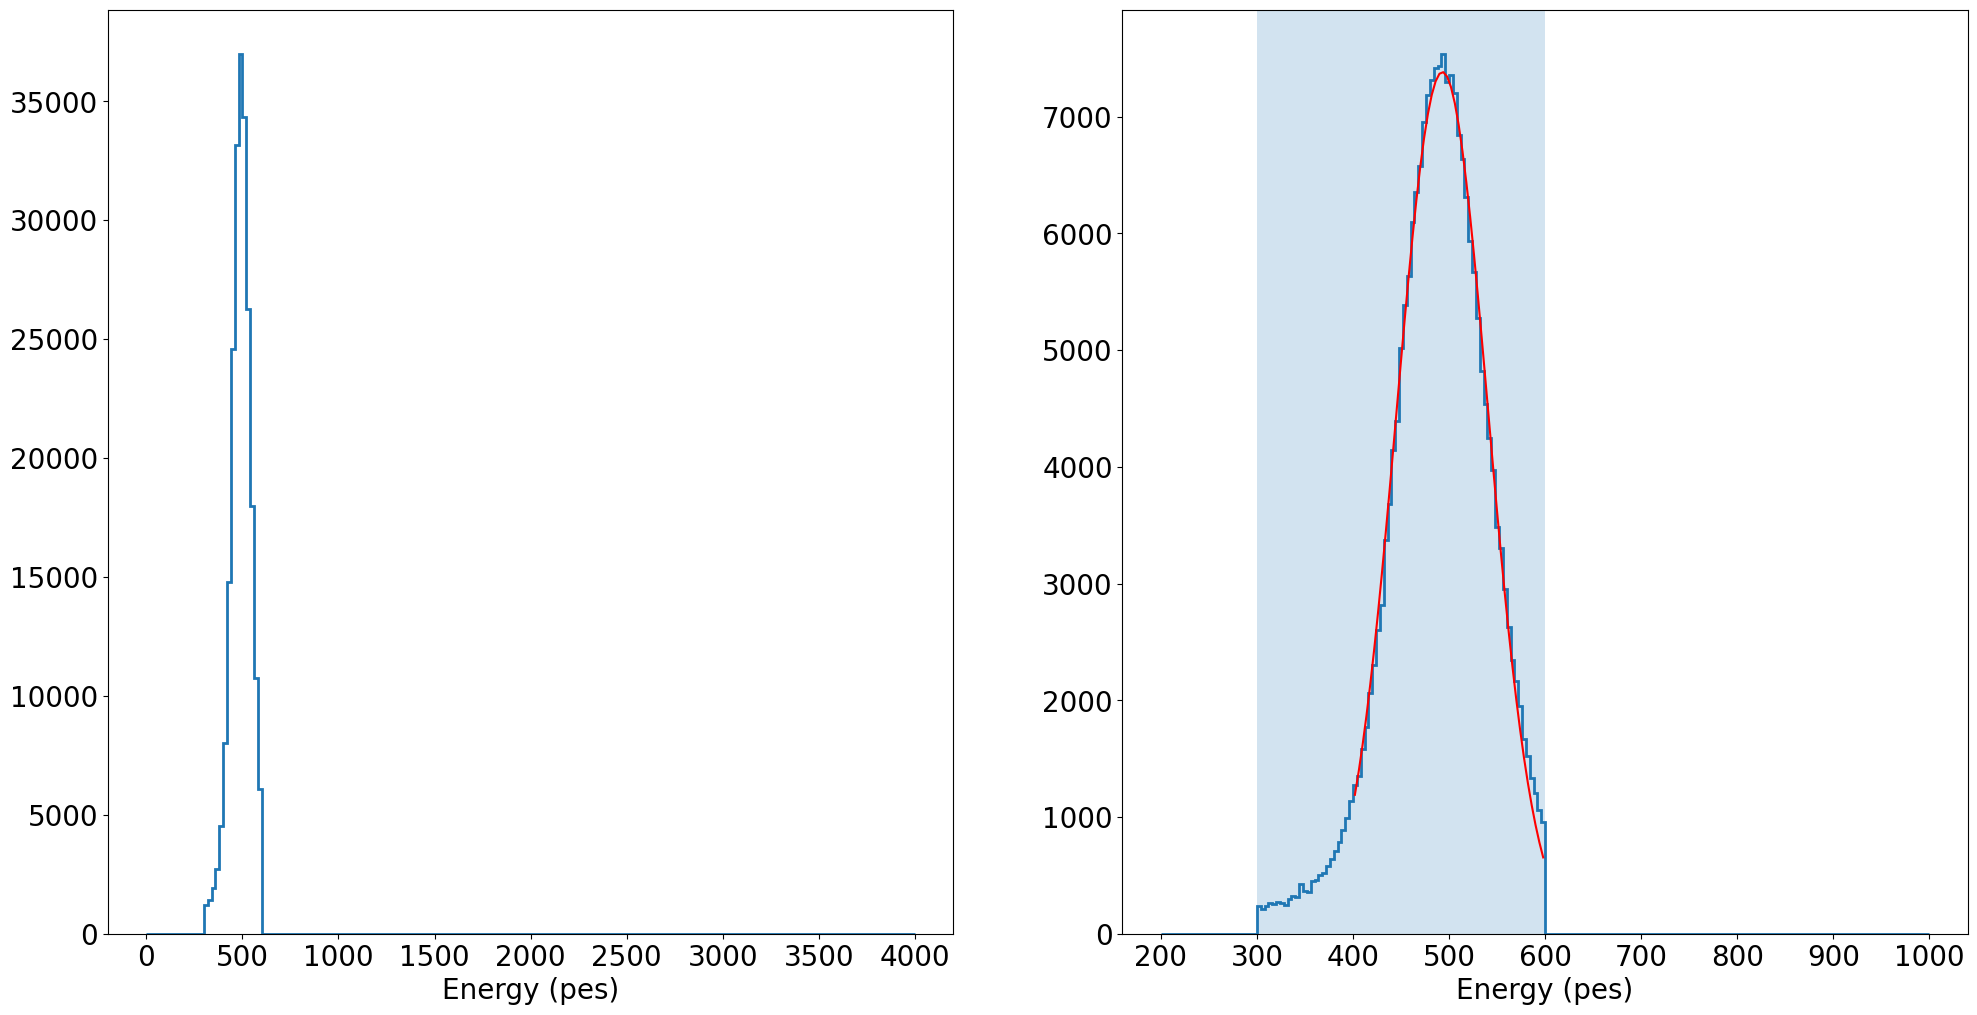

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(0, 4000, 201)
#enebins = np.linspace(0000, 400, 251)
normed = False
var    = 'energy'

eref = 2.9
#eref = 5.9

sel1 = np.full(len(data_1_s2), True)

sel1 = sel1 & sel_e_1 
#sel1 = sel1 & sel_w_1 
sel1 = sel1 & sel_ratio_1 
#sel1 = sel1 & sel_r_1
#sel1 = sel1 & sel_h_1
#wcorr_factor     = 1 / wcorr(data_1_s2['width'][sel1])
#hcorr_factor     = 1 #/ hcorr(data_1_s2['h_pmt0'][sel1])
#tcorr_factor     = 1 #/ tcorr(data_1_s2['time'][sel1])
#ratiocorr_factor = 1 #/ ratiocorr(data_1_s2['pmt_0_ratio'][sel1])
#wcorr_factor = 1 / wcorr(data_1_s2['width'][sel1])
corr = 1
#corr *= wcorr_factor
#corr *= hcorr_factor
#corr *= ratiocorr_factor
#corr *= tcorr_factor


y,x, *_ = axes[0].hist(data_1_s2[var][sel1] * corr, enebins, histtype='step', 
         lw=2, weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], label=label_1);
x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()]/eref

enebins = np.linspace(200, 1000, 201)
yd, xd, *_ = axes[1].hist(data_1_s2[var][sel1] * corr, enebins, histtype='step', 
         lw=2, weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], label=label_1);
xd = coref.shift_to_bin_centers(xd)

for ax in axes:
    #ax.set_yscale('log')
    pass

axes[0].set_xlabel('Energy (pes)')
axes[1].set_xlabel('Energy (pes)')


erange = [300, 600]
axes[1].axvspan(*erange, alpha=0.2)
sel_e_1 = coref.in_range(data_1_s2[var], *erange)

efit = [400, 600]
sel_f = coref.in_range(xd, *efit)

mod  = GaussianModel()
pars = mod.guess(yd[sel_f], x=xd[sel_f])
out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

axes[1].plot(xd[sel_f], out.best_fit, '-', c='r')

result =  out.result.params
mu     = [result['center'].value, result['center'].stderr]
sigma  = [result['sigma' ].value, result['sigma' ].stderr]
reso   = sigma[0]/mu[0] * 235
print(f'E resolution =  {reso:.2f}%')
#print(f'Intrinsic resolution = {get_intrinsic_resolution(eref*1000, fano, wi, mu[0], pmt_sigma)}%')

E resolution =  22.87%
Intrinsic resolution = 14.45795493276886%


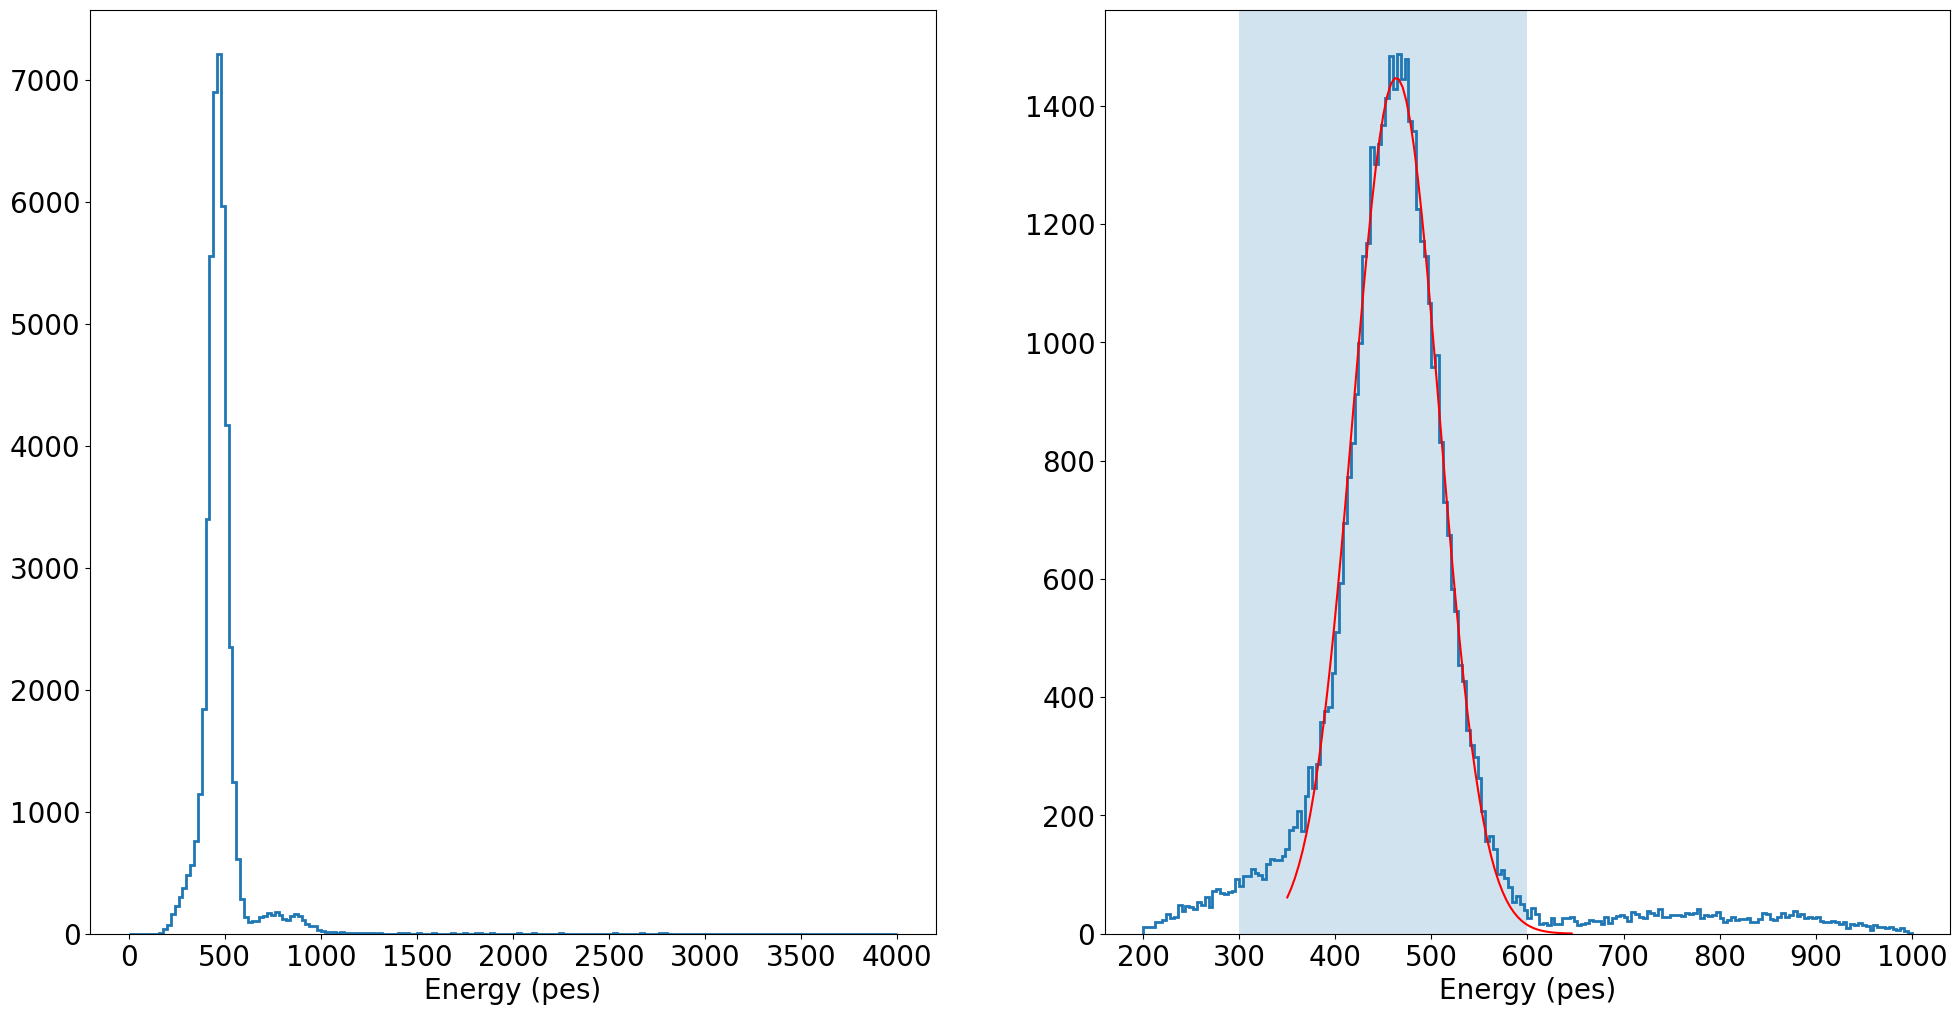

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(0, 4000, 201)
#enebins = np.linspace(0000, 400, 251)
normed = False
var    = 'energy'

eref = 2.9
#eref = 5.9

sel1 = np.full(len(data_1_s2), True)

#sel1 = sel1 #& sel_e_1 
#sel1 = sel1 & sel_w_1 
#sel1 = sel1 & sel_ratio_1 
#sel1 = sel1 & sel_r_1
#sel1 = sel1 & sel_h_1
wcorr_factor     = 1 / wcorr(data_1_s2['width'][sel1])
hcorr_factor     = 1 / hcorr(data_1_s2['h_pmt0'][sel1])
tcorr_factor     = 1 / tcorr(data_1_s2['time'][sel1])
ratiocorr_factor = 1 / ratiocorr(data_1_s2['pmt_0_ratio'][sel1])
#wcorr_factor = 1 / wcorr(data_1_s2['width'][sel1])
corr = 1
corr *= wcorr_factor
#corr *= hcorr_factor
#corr *= ratiocorr_factor
#corr *= tcorr_factor


y,x, *_ = axes[0].hist(data_1_s2[var][sel1] * corr, enebins, histtype='step', 
         lw=2, weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], label=label_1);
x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()]/eref

enebins = np.linspace(200, 1000, 201)
yd, xd, *_ = axes[1].hist(data_1_s2[var][sel1] * corr, enebins, histtype='step', 
         lw=2, weights=weights_1_s2[sel1]/len(data_1_s2) if normed else weights_1_s2[sel1], label=label_1);
xd = coref.shift_to_bin_centers(xd)

for ax in axes:
    #ax.set_yscale('log')
    pass

axes[0].set_xlabel('Energy (pes)')
axes[1].set_xlabel('Energy (pes)')


erange = [300, 600]
axes[1].axvspan(*erange, alpha=0.2)
sel_e_1 = coref.in_range(data_1_s2[var], *erange)

efit = [350, 650]
sel_f = coref.in_range(xd, *efit)

mod  = GaussianModel()
pars = mod.guess(yd[sel_f], x=xd[sel_f])
out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

axes[1].plot(xd[sel_f], out.best_fit, '-', c='r')

result =  out.result.params
mu     = [result['center'].value, result['center'].stderr]
sigma  = [result['sigma' ].value, result['sigma' ].stderr]
reso   = sigma[0]/mu[0] * 235
print(f'E resolution =  {reso:.2f}%')
print(f'Intrinsic resolution = {get_intrinsic_resolution(eref*1000, fano, wi, mu[0], pmt_sigma)}%')

E resolution =  28.16%
Intrinsic resolution = 14.949051720956648%


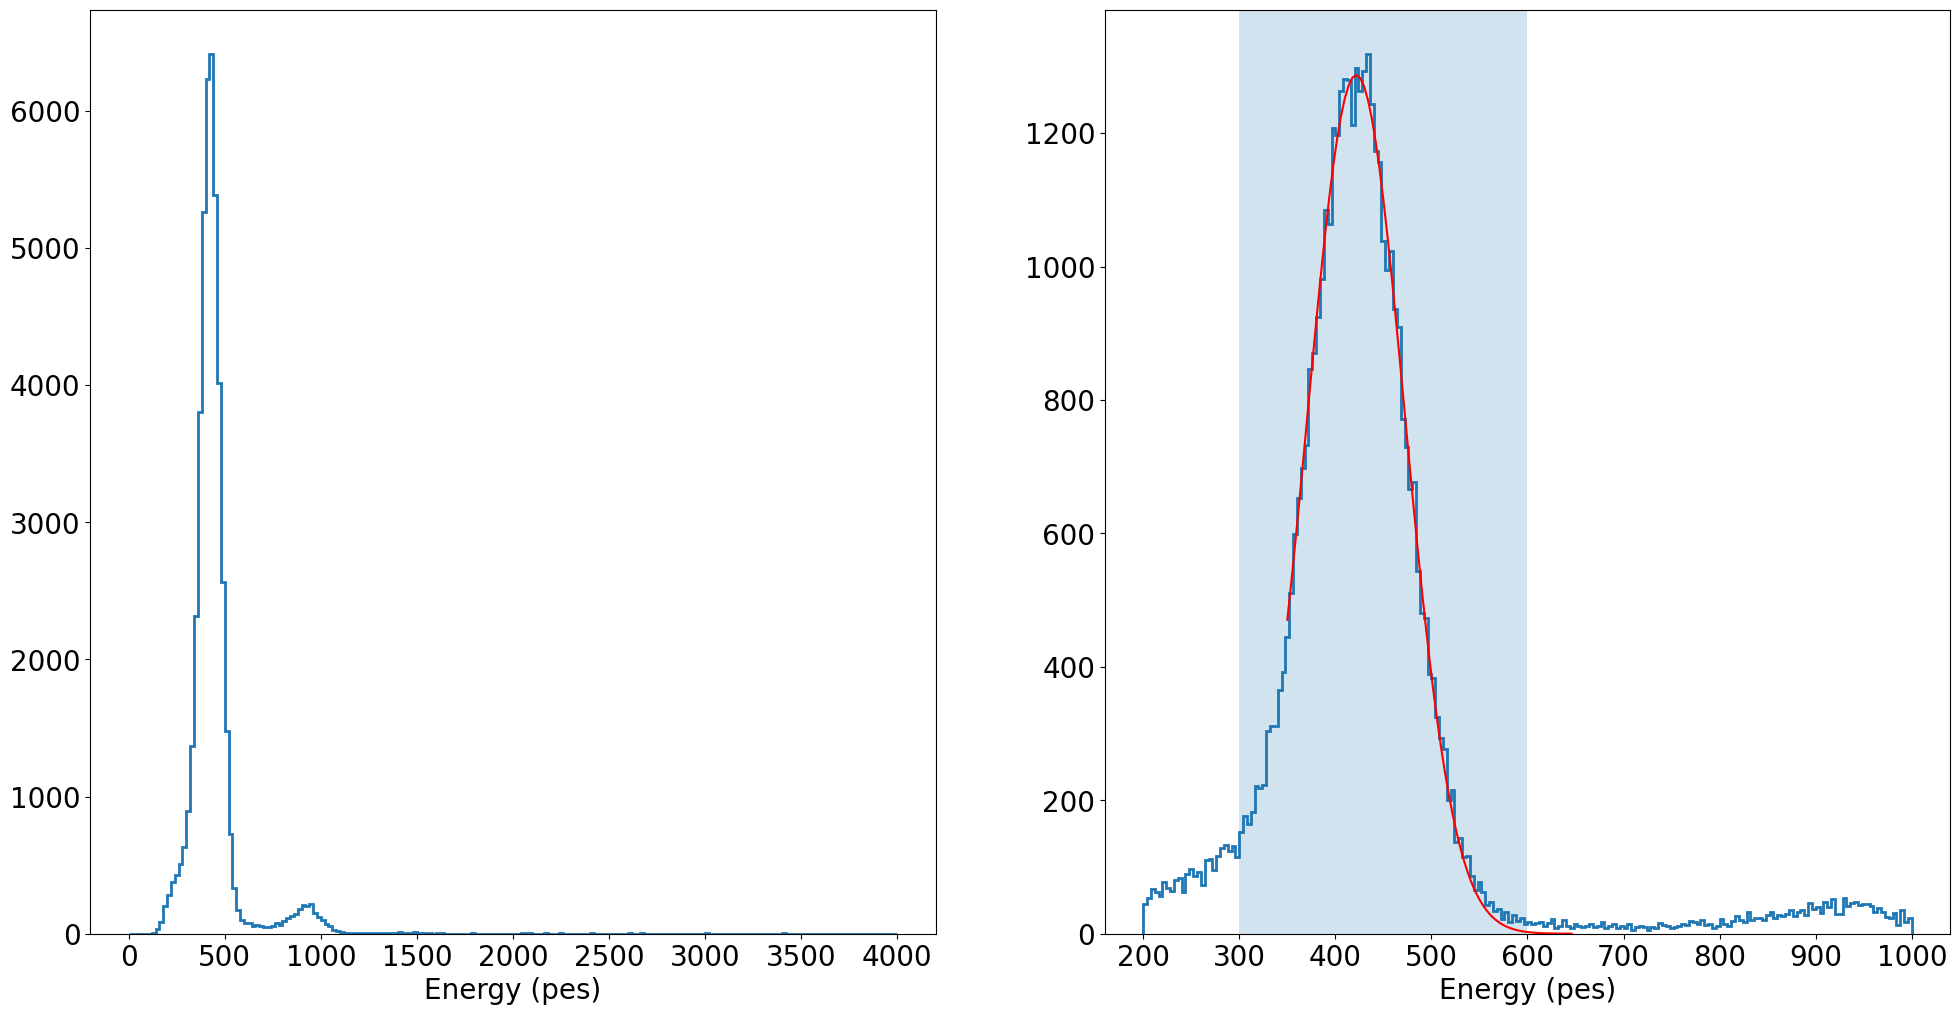

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

enebins = np.linspace(0, 4000, 201)
#enebins = np.linspace(0000, 400, 251)
normed = False
var    = 'energy'

eref = 2.9
#eref = 5.9

y,x, *_ = axes[0].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);
x = coref.shift_to_bin_centers(x)
escale_1 = x[y.argmax()]/eref

enebins = np.linspace(200, 1000, 201)
yd, xd, *_ = axes[1].hist(data_1_s2[var], enebins, histtype='step', 
         lw=2, weights=weights_1_s2/len(data_1_s2) if normed else weights_1_s2, label=label_1);
xd = coref.shift_to_bin_centers(xd)

for ax in axes:
    #ax.set_yscale('log')
    pass

axes[0].set_xlabel('Energy (pes)')
axes[1].set_xlabel('Energy (pes)')


erange = [300, 600]
axes[1].axvspan(*erange, alpha=0.2)
sel_e_1 = coref.in_range(data_1_s2[var], *erange)

efit = [350, 650]
sel_f = coref.in_range(xd, *efit)

mod  = GaussianModel()
pars = mod.guess(yd[sel_f], x=xd[sel_f])
out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

axes[1].plot(xd[sel_f], out.best_fit, '-', c='r')

result =  out.result.params
mu     = [result['center'].value, result['center'].stderr]
sigma  = [result['sigma' ].value, result['sigma' ].stderr]
reso   = sigma[0]/mu[0] * 235
print(f'E resolution =  {reso:.2f}%')
print(f'Intrinsic resolution = {get_intrinsic_resolution(eref*1000, fano, wi, mu[0], pmt_sigma)}%')

In [27]:
E = 8.5
p = 6.2

print((81*E/p - 47)*p)

397.1


In [30]:
400*5900/22

107272.72727272728

In [31]:
500/(400*5900/22)

0.004661016949152542

In [6]:
def el_yield(p, kv):
    return (81*kv/p - 47)*p

el_yield(6.2, 9.5)

478.09999999999997

In [3]:
el_yield(8.4, 11.5)

536.6999999999999

In [11]:
db.DataPMT('gap', 1).adc_to_pes

0    37.01
1    18.90
2    32.46
3    29.27
4    31.68
5    42.64
6    34.54
Name: adc_to_pes, dtype: float64

In [16]:
adc = db.DataPMT('gap', 1).adc_to_pes
print(adc/adc[0] * 120)

0    120.000000
1     61.280735
2    105.247230
3     94.904080
4    102.718184
5    138.254526
6    111.991354
Name: adc_to_pes, dtype: float64


In [13]:
60/18

3.3333333333333335

In [15]:
120/37

3.2432432432432434

In [71]:
0.649*np.sqrt(1200)

22.48201948224403

In [72]:
22/1.43

15.384615384615385